<a href="https://colab.research.google.com/github/drskprabhakar/AI-ML-DL-colab-notebooks-coding-models/blob/main/Aishwarya_sia_perfect_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [60]:
import pandas as pd
import numpy as np


In [61]:
df = pd.read_excel('/content/drive/MyDrive/Dr Aishwarya thesis clean dataset 200625.xlsx')




In [62]:
df.columns

Index(['Name', 'Age', 'Sex', 'pre-op KH', 'pre-op KV', 'pre-op Axis',
       'post-op KH', 'post-op KV', 'post-op Axis', '1 week KH', '1 week KV',
       '1 week axis'],
      dtype='object')

In [63]:
df

,Name,Age,Sex,pre-op KH,pre-op KV,pre-op Axis,post-op KH,post-op KV,post-op Axis,1 week KH,1 week KV,1 week axis
0,madappa,60,M,43.50,44.00,90,43.25,44.75,10,43.75,44.25,10
1,puttalingaiah,64,M,44.25,44.50,45,41.25,44.50,70,41.75,44.25,70
2,savitha,62,F,47.75,49.50,5,46.00,47.75,35,45.75,47.50,30
3,devamma,70,F,43.75,44.75,165,42.75,45.00,150,43.25,44.75,160
4,nanjunda naika,58,M,44.25,44.75,85,44.50,45.50,40,44.25,45.00,5
...,...,...,...,...,...,...,...,...,...,...,...,...
102,kamalamma,61,F,43.00,43.50,100,43.00,43.75,170,43.00,43.50,180
103,gundamma,54,F,45.75,46.25,30,45.75,47.00,5,46.25,45.75,15
104,sakamma,67,F,45.25,46.00,135,44.25,45.50,155,45.25,45.75,150
105,kenchangowda patil,61,M,46.00,46.50,40,46.25,48.00,5,46.25,47.00,30


In [64]:
import numpy as np
import pandas as pd

# Assuming df is your DataFrame with pre-op and post-op values

# Step 1: Cylinder calculations
df['preop-cyl'] = df['pre-op KV'] - df['pre-op KH']
df['postop-cyl'] = df['post-op KV'] - df['post-op KH']

# Step 2: Convert axis to radians (double angle)
df['theta-pre'] = np.radians(2 * df['pre-op Axis'])
df['theta-post'] = np.radians(2 * df['post-op Axis'])

# Step 3: Calculate X and Y components (note corrected Y ordering)
df['Xpre'] = df['preop-cyl'] * np.cos(df['theta-pre'])
df['Ypre'] = df['preop-cyl'] * np.sin(df['theta-pre'])

df['Xpost'] = df['postop-cyl'] * np.cos(df['theta-post'])
df['Ypost'] = df['postop-cyl'] * np.sin(df['theta-post'])

# Step 4: Calculate SIA vector components
df['Xsia'] = df['Xpost'] - df['Xpre']
df['Ysia'] = df['Ypost'] - df['Ypre']

df['SIA-Mag'] = np.sqrt(df['Xsia']**2 + df['Ysia']**2)
df['SIA-Axis'] = (np.degrees(np.arctan2(df['Ysia'], df['Xsia'])) / 2) % 180



In [65]:
df

,Name,Age,Sex,pre-op KH,pre-op KV,pre-op Axis,post-op KH,post-op KV,post-op Axis,1 week KH,...,theta-pre,theta-post,Xpre,Ypre,Xpost,Ypost,Xsia,Ysia,SIA-Mag,SIA-Axis
0,madappa,60,M,43.50,44.00,90,43.25,44.75,10,43.75,...,3.141593,0.349066,-5.000000e-01,6.123234e-17,1.409539,0.513030,1.909539,0.513030,1.977255,7.519184
1,puttalingaiah,64,M,44.25,44.50,45,41.25,44.50,70,41.75,...,1.570796,2.443461,1.530808e-17,2.500000e-01,-2.489644,2.089060,-2.489644,1.839060,3.095233,71.773661
2,savitha,62,F,47.75,49.50,5,46.00,47.75,35,45.75,...,0.174533,1.221730,1.723414e+00,3.038843e-01,0.598535,1.644462,-1.124878,1.340578,1.750000,65.000000
3,devamma,70,F,43.75,44.75,165,42.75,45.00,150,43.25,...,5.759587,5.235988,8.660254e-01,-5.000000e-01,1.125000,-1.948557,0.258975,-1.448557,1.471525,140.068156
4,nanjunda naika,58,M,44.25,44.75,85,44.50,45.50,40,44.25,...,2.967060,1.396263,-4.924039e-01,8.682409e-02,0.173648,0.984808,0.666052,0.897984,1.118034,26.717474
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102,kamalamma,61,F,43.00,43.50,100,43.00,43.75,170,43.00,...,3.490659,5.934119,-4.698463e-01,-1.710101e-01,0.704769,-0.256515,1.174616,-0.085505,1.177724,177.918276
103,gundamma,54,F,45.75,46.25,30,45.75,47.00,5,46.25,...,1.047198,0.174533,2.500000e-01,4.330127e-01,1.231010,0.217060,0.981010,-0.215952,1.004498,173.792660
104,sakamma,67,F,45.25,46.00,135,44.25,45.50,155,45.25,...,4.712389,5.410521,-1.377728e-16,-7.500000e-01,0.803485,-0.957556,0.803485,-0.207556,0.829859,172.758010
105,kenchangowda patil,61,M,46.00,46.50,40,46.25,48.00,5,46.25,...,1.396263,0.174533,8.682409e-02,4.924039e-01,1.723414,0.303884,1.636589,-0.188520,1.647412,176.714516


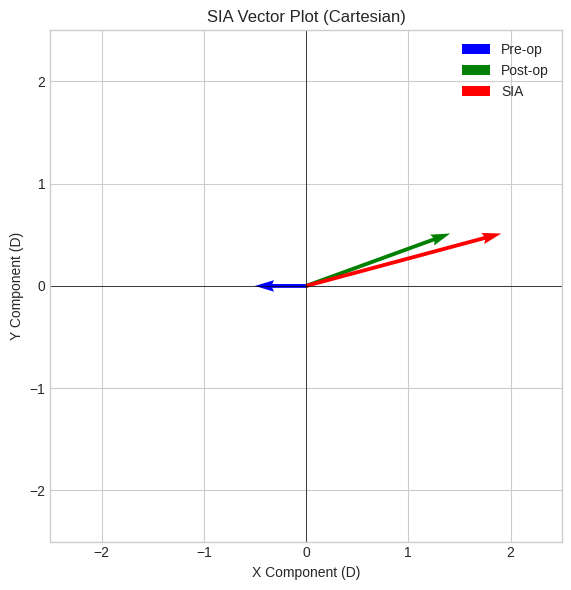

In [66]:
import matplotlib.pyplot as plt

# Given vector components
x_pre, y_pre = -0.5, 0
x_post, y_post = 1.4095, 0.5130
x_sia = x_post - x_pre
y_sia = y_post - y_pre

# Plot setup
fig, ax = plt.subplots(figsize=(6, 6))

# Plot pre-op vector (blue)
ax.quiver(0, 0, x_pre, y_pre, angles='xy', scale_units='xy', scale=1, color='blue', label='Pre-op')

# Plot post-op vector (green)
ax.quiver(0, 0, x_post, y_post, angles='xy', scale_units='xy', scale=1, color='green', label='Post-op')

# Plot SIA vector (red, using a solid line as a workaround for the dash issue)
ax.quiver(0, 0, x_sia, y_sia, angles='xy', scale_units='xy', scale=1, color='red', label='SIA')

# Axes setup
ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-2.5, 2.5)
ax.set_aspect('equal')
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('X Component (D)')
ax.set_ylabel('Y Component (D)')
ax.set_title('SIA Vector Plot (Cartesian)')
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()

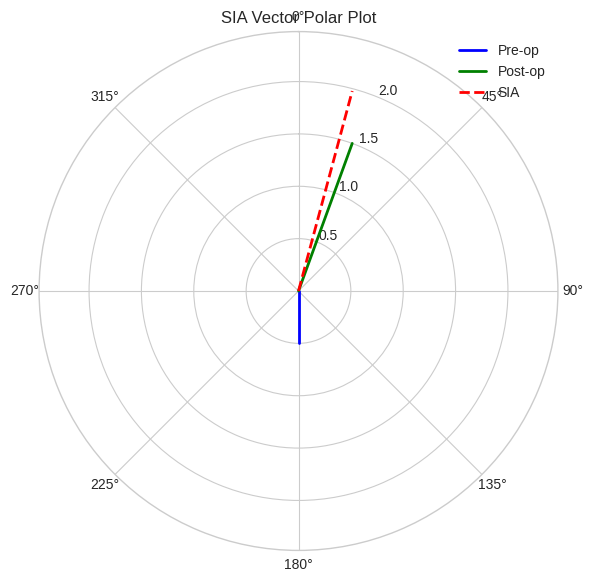

In [67]:
import numpy as np
import matplotlib.pyplot as plt

# Input values
cyl_pre = 0.50
axis_pre = 90

cyl_post = 1.50
axis_post = 10

# Step 1: Convert axis to radians (double angle for plotting)
theta_pre_rad = np.radians(2 * axis_pre)
theta_post_rad = np.radians(2 * axis_post)

# Step 2: Compute Cartesian components
x_pre = cyl_pre * np.cos(theta_pre_rad)
y_pre = cyl_pre * np.sin(theta_pre_rad)

x_post = cyl_post * np.cos(theta_post_rad)
y_post = cyl_post * np.sin(theta_post_rad)

# Step 3: Compute SIA vector
x_sia = x_post - x_pre
y_sia = y_post - y_pre

# Step 4: Convert back to polar (double angle)
mag_pre = np.sqrt(x_pre**2 + y_pre**2)
mag_post = np.sqrt(x_post**2 + y_post**2)
mag_sia = np.sqrt(x_sia**2 + y_sia**2)

theta_pre = np.arctan2(y_pre, x_pre)
theta_post = np.arctan2(y_post, x_post)
theta_sia = np.arctan2(y_sia, x_sia)

# Step 5: Polar Plot
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, polar=True)

# Plot the 3 vectors
ax.plot([theta_pre, theta_pre], [0, mag_pre], color='blue', linewidth=2, label='Pre-op')
ax.plot([theta_post, theta_post], [0, mag_post], color='green', linewidth=2, label='Post-op')
ax.plot([theta_sia, theta_sia], [0, mag_sia], color='red', linewidth=2, linestyle='--', label='SIA')

# Aesthetics
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_rmax(max(mag_pre, mag_post, mag_sia) + 0.5)
ax.set_title('SIA Vector Polar Plot')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()


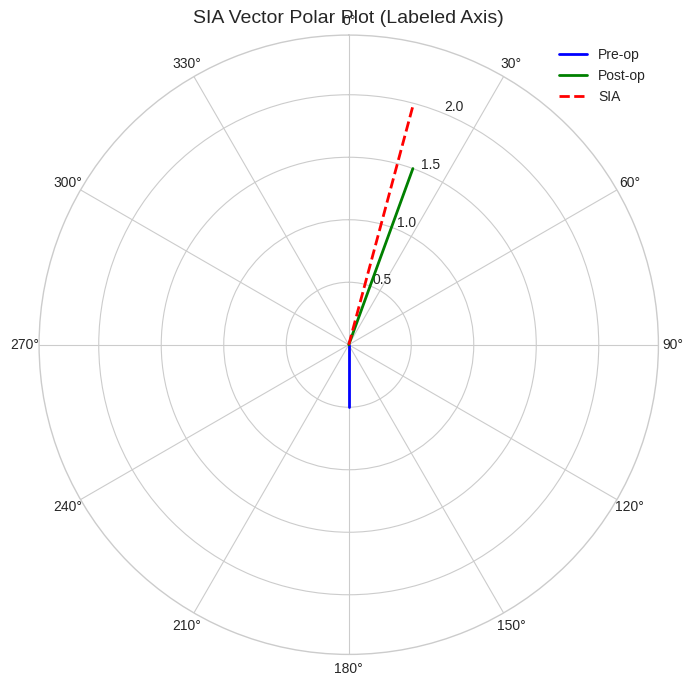

In [68]:
import numpy as np
import matplotlib.pyplot as plt

# Input values
cyl_pre = 0.50
axis_pre = 90

cyl_post = 1.50
axis_post = 10

# Convert axis to radians (double angle)
theta_pre_rad = np.radians(2 * axis_pre)
theta_post_rad = np.radians(2 * axis_post)

# Compute Cartesian components
x_pre = cyl_pre * np.cos(theta_pre_rad)
y_pre = cyl_pre * np.sin(theta_pre_rad)

x_post = cyl_post * np.cos(theta_post_rad)
y_post = cyl_post * np.sin(theta_post_rad)

# SIA vector
x_sia = x_post - x_pre
y_sia = y_post - y_pre

# Convert to polar (double angle)
mag_pre = np.hypot(x_pre, y_pre)
theta_pre = np.arctan2(y_pre, x_pre)

mag_post = np.hypot(x_post, y_post)
theta_post = np.arctan2(y_post, x_post)

mag_sia = np.hypot(x_sia, y_sia)
theta_sia = np.arctan2(y_sia, x_sia)

# Plot
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, polar=True)

# Plot vectors
ax.plot([theta_pre, theta_pre], [0, mag_pre], color='blue', linewidth=2, label='Pre-op')
ax.plot([theta_post, theta_post], [0, mag_post], color='green', linewidth=2, label='Post-op')
ax.plot([theta_sia, theta_sia], [0, mag_sia], color='red', linewidth=2, linestyle='--', label='SIA')

# Custom angle ticks (degrees on outer ring)
angle_labels = ['0°', '30°', '60°', '90°', '120°', '150°', '180°', '210°', '240°', '270°', '300°', '330°']
ax.set_thetagrids(angles=np.arange(0, 360, 30), labels=angle_labels)

# Aesthetics
ax.set_theta_zero_location('N')  # 0° at top
ax.set_theta_direction(-1)       # clockwise
ax.set_rmax(max(mag_pre, mag_post, mag_sia) + 0.5)
ax.set_title("SIA Vector Polar Plot (Labeled Axis)", va='bottom', fontsize=14)
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()


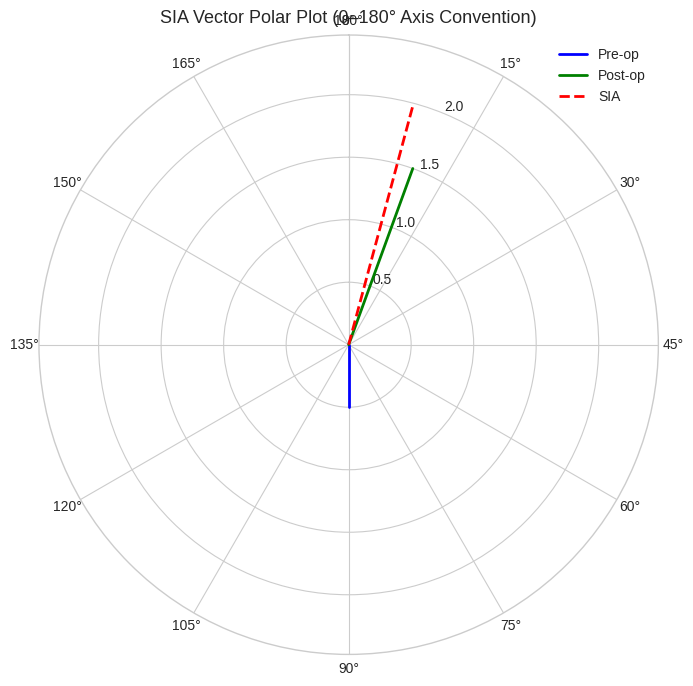

In [69]:
import numpy as np
import matplotlib.pyplot as plt

# Input values
cyl_pre = 0.50
axis_pre = 90

cyl_post = 1.50
axis_post = 10

# Convert to double-angle radians
theta_pre_rad = np.radians(2 * axis_pre)
theta_post_rad = np.radians(2 * axis_post)

# Cartesian components
x_pre = cyl_pre * np.cos(theta_pre_rad)
y_pre = cyl_pre * np.sin(theta_pre_rad)

x_post = cyl_post * np.cos(theta_post_rad)
y_post = cyl_post * np.sin(theta_post_rad)

# SIA vector
x_sia = x_post - x_pre
y_sia = y_post - y_pre

# Convert to polar
mag_pre = np.hypot(x_pre, y_pre)
theta_pre = np.arctan2(y_pre, x_pre)

mag_post = np.hypot(x_post, y_post)
theta_post = np.arctan2(y_post, x_post)

mag_sia = np.hypot(x_sia, y_sia)
theta_sia = np.arctan2(y_sia, x_sia)

# Plot
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, polar=True)

# Plot vectors
ax.plot([theta_pre, theta_pre], [0, mag_pre], color='blue', linewidth=2, label='Pre-op')
ax.plot([theta_post, theta_post], [0, mag_post], color='green', linewidth=2, label='Post-op')
ax.plot([theta_sia, theta_sia], [0, mag_sia], color='red', linewidth=2, linestyle='--', label='SIA')

# Customize astigmatism-style axis labels (0° to 180° only)
half_circle_deg = np.arange(0, 181, 15)
half_circle_rad = np.radians(half_circle_deg * 2)  # double angle for plotting
ax.set_thetagrids(angles=half_circle_rad * 180 / np.pi, labels=[f"{d}°" for d in half_circle_deg])

# Aesthetics
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_rmax(max(mag_pre, mag_post, mag_sia) + 0.5)
ax.set_title("SIA Vector Polar Plot (0–180° Axis Convention)", fontsize=13, va='bottom')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()


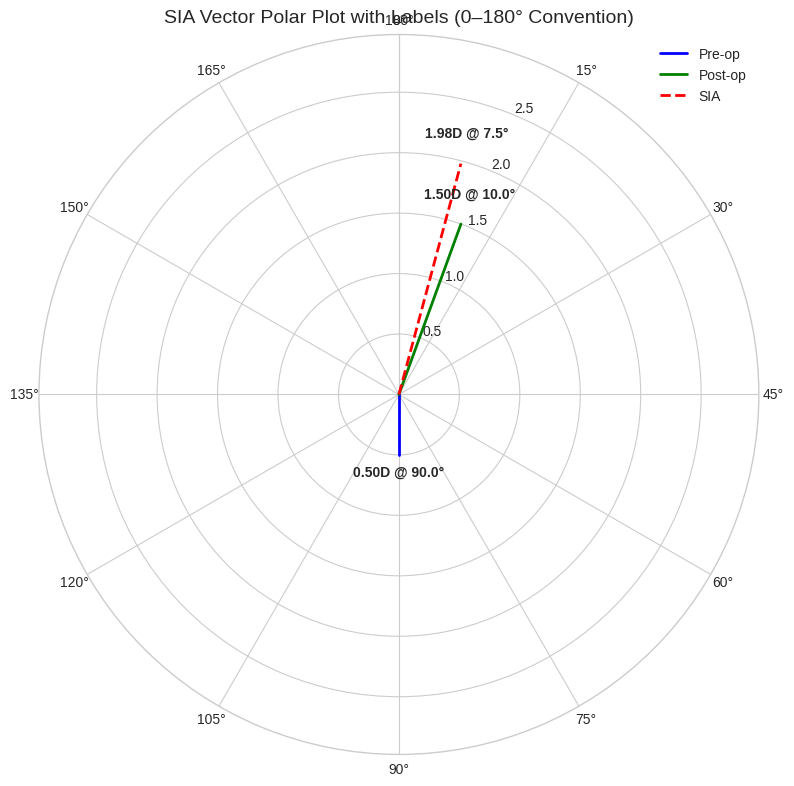

In [70]:
import numpy as np
import matplotlib.pyplot as plt

# Patient data
cyl_pre = 0.50
axis_pre = 90
cyl_post = 1.50
axis_post = 10

# Double angle (radians)
theta_pre_rad = np.radians(2 * axis_pre)
theta_post_rad = np.radians(2 * axis_post)

# Cartesian coordinates
x_pre = cyl_pre * np.cos(theta_pre_rad)
y_pre = cyl_pre * np.sin(theta_pre_rad)
x_post = cyl_post * np.cos(theta_post_rad)
y_post = cyl_post * np.sin(theta_post_rad)
x_sia = x_post - x_pre
y_sia = y_post - y_pre

# Polar conversion (half-angle back to single-angle convention)
mag_pre = np.hypot(x_pre, y_pre)
axis_pre_plot = (np.degrees(np.arctan2(y_pre, x_pre)) / 2) % 180

mag_post = np.hypot(x_post, y_post)
axis_post_plot = (np.degrees(np.arctan2(y_post, x_post)) / 2) % 180

mag_sia = np.hypot(x_sia, y_sia)
axis_sia_plot = (np.degrees(np.arctan2(y_sia, x_sia)) / 2) % 180

# Convert to radians for plotting (double-angle)
theta_pre_plot = np.radians(axis_pre_plot * 2)
theta_post_plot = np.radians(axis_post_plot * 2)
theta_sia_plot = np.radians(axis_sia_plot * 2)

# Polar plot setup
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, polar=True)

# Plot vectors
ax.plot([theta_pre_plot, theta_pre_plot], [0, mag_pre], color='blue', linewidth=2, label='Pre-op')
ax.plot([theta_post_plot, theta_post_plot], [0, mag_post], color='green', linewidth=2, label='Post-op')
ax.plot([theta_sia_plot, theta_sia_plot], [0, mag_sia], color='red', linewidth=2, linestyle='--', label='SIA')

# Add magnitude and axis labels near arrowheads
def add_vector_label(theta, mag, label_text, offset=0.2):
    r = mag + offset
    ax.text(theta, r, label_text, ha='center', va='bottom', fontsize=10, fontweight='bold')

add_vector_label(theta_pre_plot, mag_pre, f"{mag_pre:.2f}D @ {axis_pre_plot:.1f}°")
add_vector_label(theta_post_plot, mag_post, f"{mag_post:.2f}D @ {axis_post_plot:.1f}°")
add_vector_label(theta_sia_plot, mag_sia, f"{mag_sia:.2f}D @ {axis_sia_plot:.1f}°")

# Customize 0–180° axis
half_circle_deg = np.arange(0, 181, 15)
half_circle_rad = np.radians(half_circle_deg * 2)  # double-angle for plotting
ax.set_thetagrids(angles=half_circle_rad * 180 / np.pi, labels=[f"{d}°" for d in half_circle_deg])

# Styling
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_rmax(max(mag_pre, mag_post, mag_sia) + 1)
ax.set_title("SIA Vector Polar Plot with Labels (0–180° Convention)", fontsize=14, va='bottom')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()


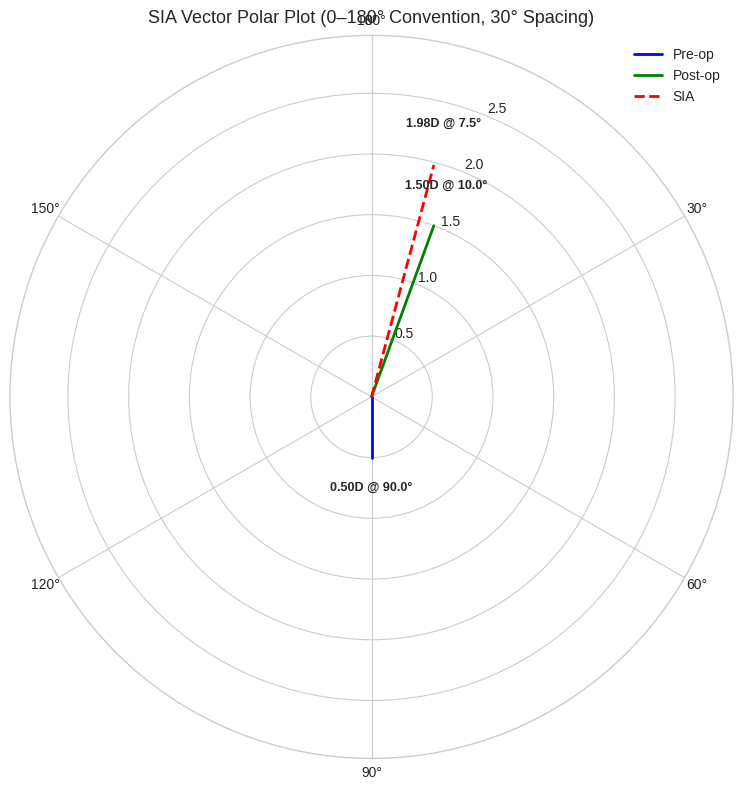

In [71]:
import numpy as np
import matplotlib.pyplot as plt

# Patient data
cyl_pre = 0.50
axis_pre = 90
cyl_post = 1.50
axis_post = 10

# Convert to double-angle (radians)
theta_pre_rad = np.radians(2 * axis_pre)
theta_post_rad = np.radians(2 * axis_post)

# Cartesian components
x_pre = cyl_pre * np.cos(theta_pre_rad)
y_pre = cyl_pre * np.sin(theta_pre_rad)
x_post = cyl_post * np.cos(theta_post_rad)
y_post = cyl_post * np.sin(theta_post_rad)
x_sia = x_post - x_pre
y_sia = y_post - y_pre

# Convert to polar (back to single-angle convention)
mag_pre = np.hypot(x_pre, y_pre)
axis_pre_plot = (np.degrees(np.arctan2(y_pre, x_pre)) / 2) % 180

mag_post = np.hypot(x_post, y_post)
axis_post_plot = (np.degrees(np.arctan2(y_post, x_post)) / 2) % 180

mag_sia = np.hypot(x_sia, y_sia)
axis_sia_plot = (np.degrees(np.arctan2(y_sia, x_sia)) / 2) % 180

# Convert back to radians (double angle for plotting)
theta_pre_plot = np.radians(axis_pre_plot * 2)
theta_post_plot = np.radians(axis_post_plot * 2)
theta_sia_plot = np.radians(axis_sia_plot * 2)

# Start polar plot
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, polar=True)

# Plot the vectors
ax.plot([theta_pre_plot, theta_pre_plot], [0, mag_pre], color='blue', linewidth=2, label='Pre-op')
ax.plot([theta_post_plot, theta_post_plot], [0, mag_post], color='green', linewidth=2, label='Post-op')
ax.plot([theta_sia_plot, theta_sia_plot], [0, mag_sia], color='red', linewidth=2, linestyle='--', label='SIA')

# Add vector labels (magnitude and axis)
def add_vector_label(theta, mag, text, offset=0.3):
    ax.text(theta, mag + offset, text, ha='center', va='bottom', fontsize=9, fontweight='bold')

add_vector_label(theta_pre_plot, mag_pre, f"{mag_pre:.2f}D @ {axis_pre_plot:.1f}°")
add_vector_label(theta_post_plot, mag_post, f"{mag_post:.2f}D @ {axis_post_plot:.1f}°")
add_vector_label(theta_sia_plot, mag_sia, f"{mag_sia:.2f}D @ {axis_sia_plot:.1f}°")

# Axis ticks: 0–180° with 30° spacing
ticks_deg = np.arange(0, 181, 30)
ticks_rad = np.radians(ticks_deg * 2)  # Double angle for plotting
ax.set_thetagrids(ticks_rad * 180 / np.pi, labels=[f"{deg}°" for deg in ticks_deg])

# Aesthetics
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_rmax(max(mag_pre, mag_post, mag_sia) + 1)
ax.set_title("SIA Vector Polar Plot (0–180° Convention, 30° Spacing)", fontsize=13, va='bottom')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()


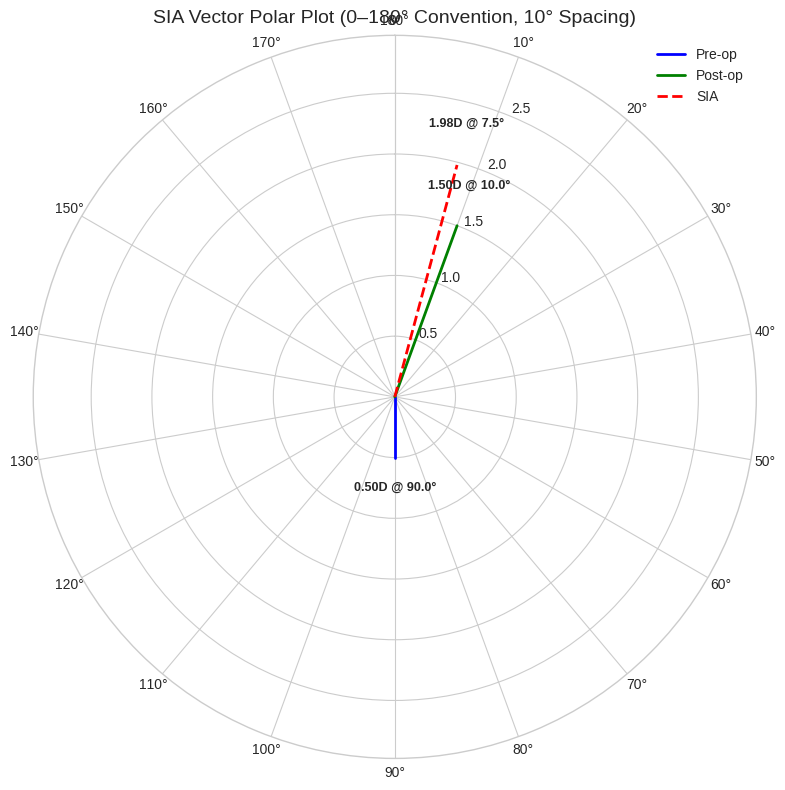

In [72]:
import numpy as np
import matplotlib.pyplot as plt

# Patient data
cyl_pre = 0.50
axis_pre = 90
cyl_post = 1.50
axis_post = 10

# Convert to double-angle radians
theta_pre_rad = np.radians(2 * axis_pre)
theta_post_rad = np.radians(2 * axis_post)

# Cartesian coordinates
x_pre = cyl_pre * np.cos(theta_pre_rad)
y_pre = cyl_pre * np.sin(theta_pre_rad)
x_post = cyl_post * np.cos(theta_post_rad)
y_post = cyl_post * np.sin(theta_post_rad)
x_sia = x_post - x_pre
y_sia = y_post - y_pre

# Convert to polar for plotting (single-angle)
mag_pre = np.hypot(x_pre, y_pre)
axis_pre_plot = (np.degrees(np.arctan2(y_pre, x_pre)) / 2) % 180

mag_post = np.hypot(x_post, y_post)
axis_post_plot = (np.degrees(np.arctan2(y_post, x_post)) / 2) % 180

mag_sia = np.hypot(x_sia, y_sia)
axis_sia_plot = (np.degrees(np.arctan2(y_sia, x_sia)) / 2) % 180

# Convert angles back to double-angle radians for plotting
theta_pre_plot = np.radians(axis_pre_plot * 2)
theta_post_plot = np.radians(axis_post_plot * 2)
theta_sia_plot = np.radians(axis_sia_plot * 2)

# Set up polar plot
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, polar=True)

# Plot the vectors
ax.plot([theta_pre_plot, theta_pre_plot], [0, mag_pre], color='blue', linewidth=2, label='Pre-op')
ax.plot([theta_post_plot, theta_post_plot], [0, mag_post], color='green', linewidth=2, label='Post-op')
ax.plot([theta_sia_plot, theta_sia_plot], [0, mag_sia], color='red', linewidth=2, linestyle='--', label='SIA')

# Label vectors
def add_vector_label(theta, mag, text, offset=0.3):
    ax.text(theta, mag + offset, text, ha='center', va='bottom', fontsize=9, fontweight='bold')

add_vector_label(theta_pre_plot, mag_pre, f"{mag_pre:.2f}D @ {axis_pre_plot:.1f}°")
add_vector_label(theta_post_plot, mag_post, f"{mag_post:.2f}D @ {axis_post_plot:.1f}°")
add_vector_label(theta_sia_plot, mag_sia, f"{mag_sia:.2f}D @ {axis_sia_plot:.1f}°")

# Axis ticks: every 10 degrees (0–180°)
ticks_deg = np.arange(0, 181, 10)
ticks_rad = np.radians(ticks_deg * 2)  # double-angle for plotting
ax.set_thetagrids(ticks_rad * 180 / np.pi, labels=[f"{deg}°" for deg in ticks_deg])

# Final aesthetics
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_rmax(max(mag_pre, mag_post, mag_sia) + 1)
ax.set_title("SIA Vector Polar Plot (0–180° Convention, 10° Spacing)", fontsize=14, va='bottom')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()


SIA Magnitude: 1.98 D
SIA Axis: 7.5°


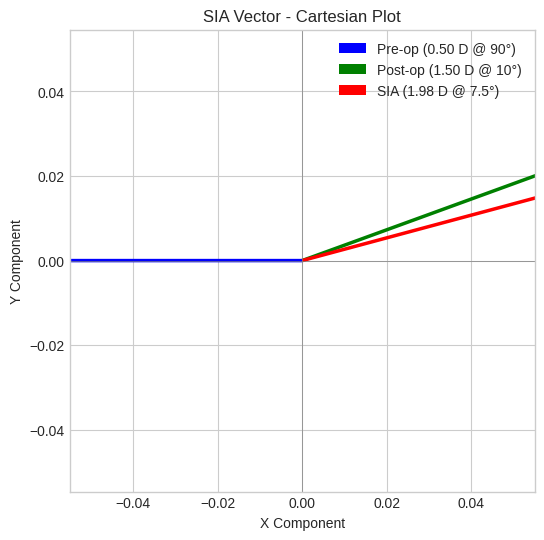

In [73]:
import matplotlib.pyplot as plt
import numpy as np

# ==== Input Data ====
# Pre-op K-values and axis
KH_pre = 43.50
KV_pre = 44.00
axis_pre = 90

# Post-op K-values and axis
KH_post = 43.25
KV_post = 44.75
axis_post = 10

# ==== Step 1: Convert K-values to Cylindrical Form ====
cyl_pre = KV_pre - KH_pre   # = +0.50 D
cyl_post = KV_post - KH_post  # = +1.50 D

# ==== Step 2: Convert to Cartesian Vectors (Double Angle) ====
# Pre-op vector
angle_pre_rad = np.deg2rad(2 * axis_pre)
x_pre = cyl_pre * np.cos(angle_pre_rad)
y_pre = cyl_pre * np.sin(angle_pre_rad)

# Post-op vector
angle_post_rad = np.deg2rad(2 * axis_post)
x_post = cyl_post * np.cos(angle_post_rad)
y_post = cyl_post * np.sin(angle_post_rad)

# ==== Step 3: Compute SIA Vector ====
x_sia = x_post - x_pre
y_sia = y_post - y_pre

sia_magnitude = np.sqrt(x_sia**2 + y_sia**2)
sia_angle_double = np.rad2deg(np.arctan2(y_sia, x_sia))
sia_axis = (sia_angle_double / 2) % 180  # Ensure axis is between 0–180°

print(f"SIA Magnitude: {sia_magnitude:.2f} D")
print(f"SIA Axis: {sia_axis:.1f}°")

# ==== Step 4: Plot Cartesian Vectors ====
plt.figure(figsize=(6, 6))
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)

# Vectors
plt.quiver(0, 0, x_pre, y_pre, angles='xy', scale_units='xy', scale=1, color='blue', label=f'Pre-op ({cyl_pre:.2f} D @ {axis_pre}°)')
plt.quiver(0, 0, x_post, y_post, angles='xy', scale_units='xy', scale=1, color='green', label=f'Post-op ({cyl_post:.2f} D @ {axis_post}°)')
plt.quiver(0, 0, x_sia, y_sia, angles='xy', scale_units='xy', scale=1, color='red', linewidth=2, label=f'SIA ({sia_magnitude:.2f} D @ {sia_axis:.1f}°)')

# Formatting
plt.title("SIA Vector - Cartesian Plot")
plt.xlabel("X Component")
plt.ylabel("Y Component")
plt.grid(True)
plt.axis('equal')
plt.legend()
plt.show()


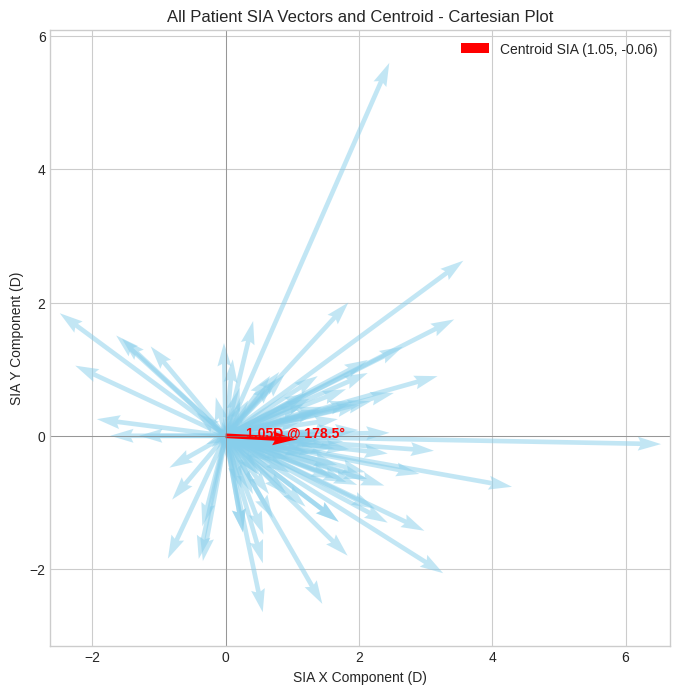

In [75]:
# prompt: Show sia vector for all patients in Cartesian plot for centroid

import matplotlib.pyplot as plt
import numpy as np
# Assuming df contains 'Xsia' and 'Ysia' columns already calculated

# Calculate the centroid of the SIA vectors
centroid_X = df['Xsia'].mean()
centroid_Y = df['Ysia'].mean()

plt.figure(figsize=(8, 8))
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)

# Plot each individual patient's SIA vector
for index, row in df.iterrows():
    plt.quiver(0, 0, row['Xsia'], row['Ysia'], angles='xy', scale_units='xy', scale=1, color='skyblue', alpha=0.5)

# Plot the centroid SIA vector
plt.quiver(0, 0, centroid_X, centroid_Y, angles='xy', scale_units='xy', scale=1, color='red', linewidth=3, label=f'Centroid SIA ({centroid_X:.2f}, {centroid_Y:.2f})')

# Calculate centroid magnitude and axis for label
centroid_mag = np.sqrt(centroid_X**2 + centroid_Y**2)
centroid_axis_double_angle = np.arctan2(centroid_Y, centroid_X)
centroid_axis_single_angle = (np.degrees(centroid_axis_double_angle) / 2) % 180

# Add label to centroid vector
plt.text(centroid_X, centroid_Y, f'{centroid_mag:.2f}D @ {centroid_axis_single_angle:.1f}°',
         fontsize=10, ha='center', va='bottom', color='red', fontweight='bold')

# Formatting
plt.title("All Patient SIA Vectors and Centroid - Cartesian Plot")
plt.xlabel("SIA X Component (D)")
plt.ylabel("SIA Y Component (D)")
plt.grid(True)
plt.axis('equal') # Ensure equal scaling for proper vector representation
plt.xlim(df['Xsia'].min() - 0.5, df['Xsia'].max() + 0.5) # Adjust limits based on data
plt.ylim(df['Ysia'].min() - 0.5, df['Ysia'].max() + 0.5) # Adjust limits based on data
plt.legend()
plt.show()

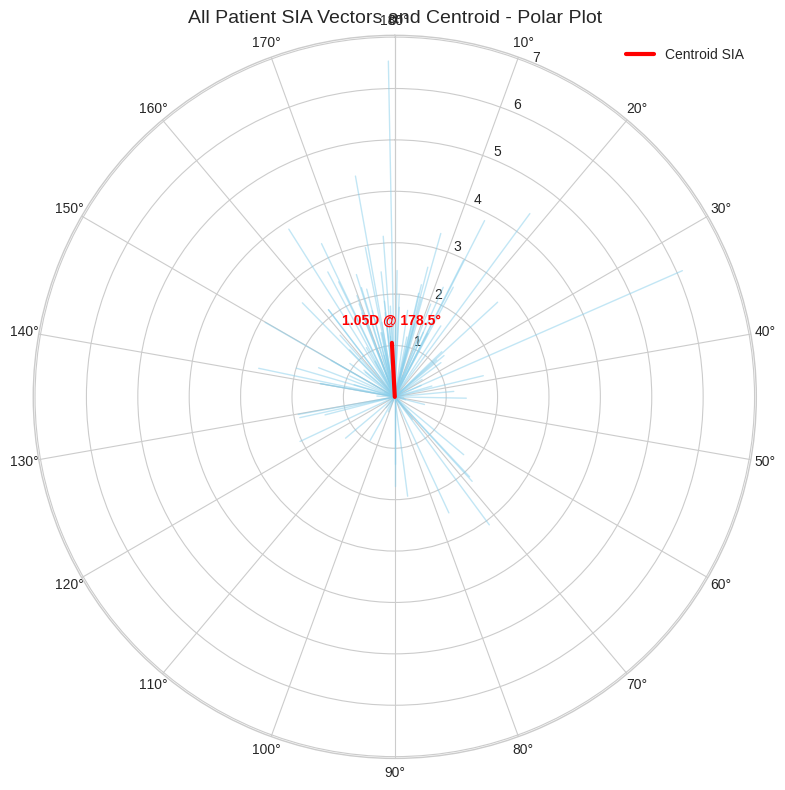

In [76]:
# prompt: Show sia vector for all patients in polar plot for centroid

import matplotlib.pyplot as plt
import numpy as np
# Assuming df contains 'Xsia' and 'Ysia' columns already calculated

# Calculate the centroid of the SIA vectors
centroid_X = df['Xsia'].mean()
centroid_Y = df['Ysia'].mean()

# Convert centroid to polar (double angle) for plotting
centroid_mag = np.hypot(centroid_X, centroid_Y)
centroid_theta_rad = np.arctan2(centroid_Y, centroid_X) # This is already the double angle in radians

# Convert individual SIA vectors to polar (double angle) for plotting
df['SIA-Theta-Plot'] = np.arctan2(df['Ysia'], df['Xsia'])

# Set up polar plot
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, polar=True)

# Plot each individual patient's SIA vector
for index, row in df.iterrows():
    ax.plot([0, row['SIA-Theta-Plot']], [0, row['SIA-Mag']], color='skyblue', alpha=0.5, linewidth=1)

# Plot the centroid SIA vector
ax.plot([0, centroid_theta_rad], [0, centroid_mag], color='red', linewidth=3, label=f'Centroid SIA')

# Add magnitude and axis label to centroid vector
# Convert centroid double angle radian to single angle degree for label
centroid_axis_single_angle = (np.degrees(centroid_theta_rad) / 2) % 180
ax.text(centroid_theta_rad, centroid_mag + 0.3, f"{centroid_mag:.2f}D @ {centroid_axis_single_angle:.1f}°",
        ha='center', va='bottom', fontsize=10, fontweight='bold', color='red')


# Customize axis ticks: 0–180° with 10° spacing
ticks_deg = np.arange(0, 181, 10)
ticks_rad = np.radians(ticks_deg * 2)  # double-angle for plotting
ax.set_thetagrids(ticks_rad * 180 / np.pi, labels=[f"{deg}°" for deg in ticks_deg])


# Styling
ax.set_theta_zero_location('N')  # 0° at the top
ax.set_theta_direction(-1)       # Clockwise direction
ax.set_rmax(df['SIA-Mag'].max() + 0.5) # Adjust rmax based on max SIA magnitude
ax.set_title("All Patient SIA Vectors and Centroid - Polar Plot", fontsize=14, va='bottom')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [16]:
# prompt: Descriptive statistics for sia magnitude and axis

print("\nDescriptive Statistics for SIA Magnitude:")
print(df['SIA-Mag'].describe())

print("\nDescriptive Statistics for SIA Axis:")
print(df['SIA-Axis'].describe())


Descriptive Statistics for SIA Magnitude:
count    107.000000
mean       1.786961
std        1.086317
min        0.174311
25%        1.135210
50%        1.646684
75%        2.225146
max        6.534689
Name: SIA-Mag, dtype: float64

Descriptive Statistics for SIA Axis:
count    107.000000
mean     102.081797
std       67.800456
min        0.518773
25%       25.858737
50%      128.833415
75%      168.258304
max      180.000000
Name: SIA-Axis, dtype: float64


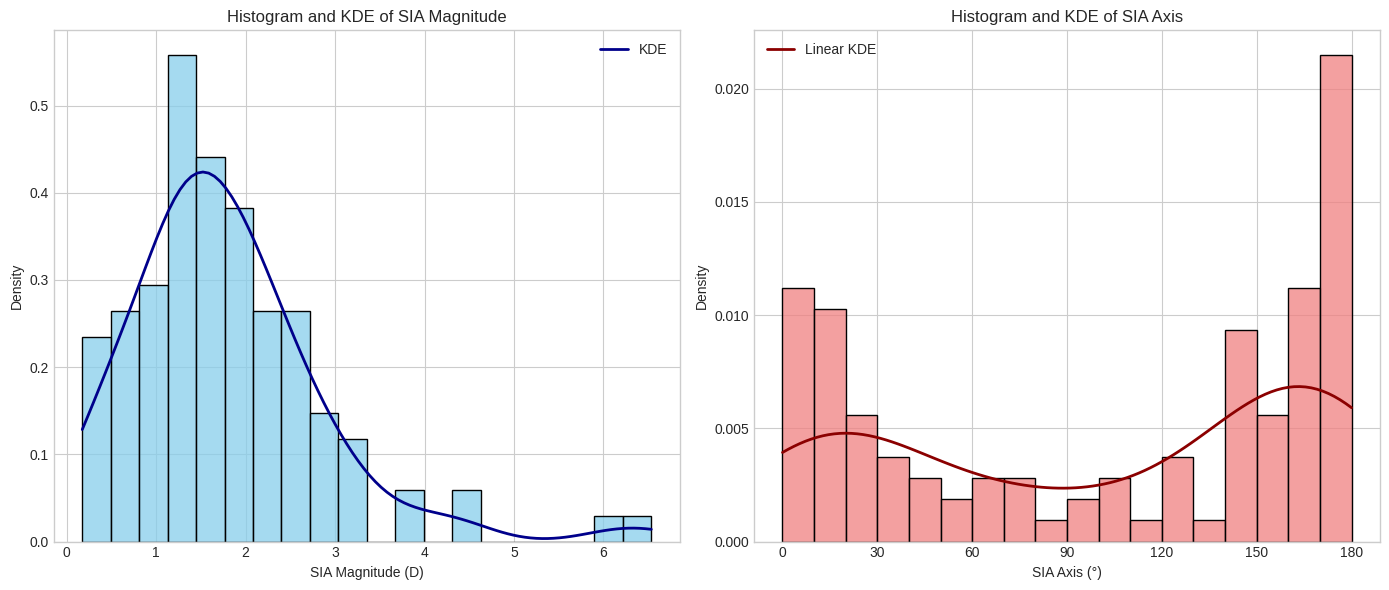

In [18]:
# prompt: Histogram sia magnitude and axis with curve

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import gaussian_kde

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')

# Create subplots for magnitude and axis
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Plot SIA Magnitude Histogram with KDE ---
ax1 = axes[0]
sns.histplot(data=df, x='SIA-Mag', bins=20, kde=False, color='skyblue', ax=ax1, stat='density') # Use stat='density'

# Calculate KDE for magnitude
kde_mag = gaussian_kde(df['SIA-Mag'].dropna()) # Drop NaNs for KDE calculation
x_mag_kde = np.linspace(df['SIA-Mag'].min(), df['SIA-Mag'].max(), 100)
y_mag_kde = kde_mag(x_mag_kde)
ax1.plot(x_mag_kde, y_mag_kde, color='darkblue', linewidth=2, label='KDE')


ax1.set_title('Histogram and KDE of SIA Magnitude')
ax1.set_xlabel('SIA Magnitude (D)')
ax1.set_ylabel('Density')
ax1.legend()


# --- Plot SIA Axis Histogram with KDE ---
ax2 = axes[1]
# Define custom bins for axis (0 to 180 degrees)
axis_bins = np.arange(0, 181, 10) # Bins every 10 degrees
sns.histplot(data=df, x='SIA-Axis', bins=axis_bins, kde=False, color='lightcoral', ax=ax2, stat='density') # Use stat='density'

# Calculate KDE for axis - need to handle the circular nature or use a library like `circular_kde` if available
# For a simple visualization, we can use linear KDE, but be aware it doesn't handle the 0/180 wrap-around correctly
kde_axis = gaussian_kde(df['SIA-Axis'].dropna()) # Drop NaNs for KDE calculation
x_axis_kde = np.linspace(0, 180, 100)
y_axis_kde = kde_axis(x_axis_kde)
ax2.plot(x_axis_kde, y_axis_kde, color='darkred', linewidth=2, label='Linear KDE') # Label clearly as Linear KDE


ax2.set_title('Histogram and KDE of SIA Axis')
ax2.set_xlabel('SIA Axis (°)')
ax2.set_ylabel('Density')
ax2.set_xticks(np.arange(0, 181, 30)) # Set x-ticks for clarity
ax2.legend()


plt.tight_layout()
plt.show()

/tmp/ipython-input-20-3587295321.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Operation', y='Cylinder', data=df_stacked, palette={'Pre-op': 'blue', 'Post-op': 'green'})


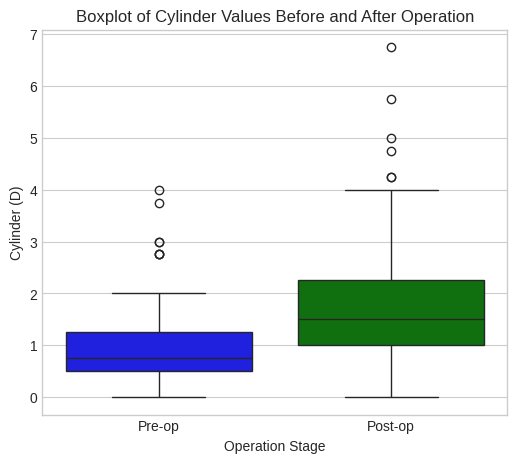

In [20]:
# prompt: Boxplot side by side

import matplotlib.pyplot as plt
# Prepare data for boxplots
# Stack the data so pre-op and post-op values are in one column with a category indicator
df_stacked = df[['preop-cyl', 'postop-cyl']].melt(var_name='Operation', value_name='Cylinder')
df_stacked['Operation'] = df_stacked['Operation'].replace({'preop-cyl': 'Pre-op', 'postop-cyl': 'Post-op'})

# Create the boxplot
plt.figure(figsize=(6, 5))
sns.boxplot(x='Operation', y='Cylinder', data=df_stacked, palette={'Pre-op': 'blue', 'Post-op': 'green'})
plt.title('Boxplot of Cylinder Values Before and After Operation')
plt.xlabel('Operation Stage')
plt.ylabel('Cylinder (D)')
plt.show()

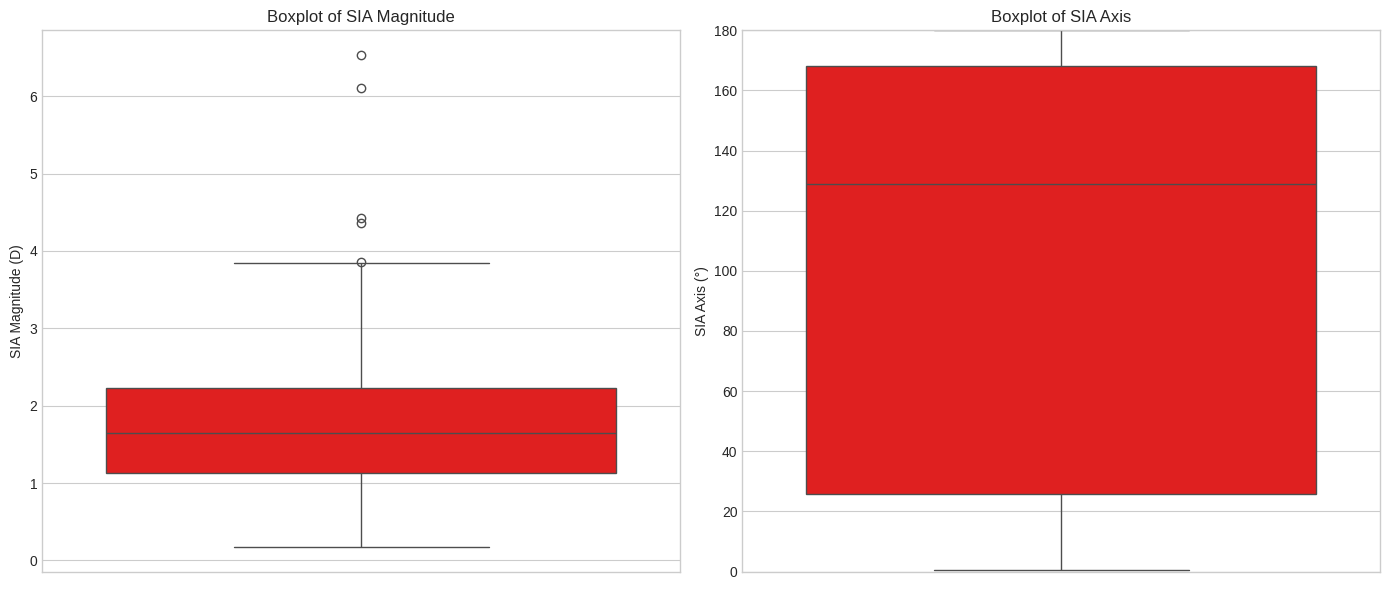

In [21]:
# prompt: Boxplot sia magnitude and axis

import matplotlib.pyplot as plt
# Prepare data for boxplots of SIA Magnitude and SIA Axis
df_sia_stacked = df[['SIA-Mag', 'SIA-Axis']].melt(var_name='Parameter', value_name='Value')

# Create the boxplot figure
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot for SIA Magnitude
sns.boxplot(ax=axes[0], y='Value', data=df_sia_stacked[df_sia_stacked['Parameter'] == 'SIA-Mag'], color='red')
axes[0].set_title('Boxplot of SIA Magnitude')
axes[0].set_ylabel('SIA Magnitude (D)')
axes[0].set_xlabel('') # Remove xlabel for a cleaner look if only one box

# Boxplot for SIA Axis
sns.boxplot(ax=axes[1], y='Value', data=df_sia_stacked[df_sia_stacked['Parameter'] == 'SIA-Axis'], color='red')
axes[1].set_title('Boxplot of SIA Axis')
axes[1].set_ylabel('SIA Axis (°)')
axes[1].set_xlabel('') # Remove xlabel for a cleaner look if only one box
axes[1].set_ylim(0, 180) # Set axis limits for clarity

plt.tight_layout()
plt.show()

In [30]:
# prompt: Prediction analysis

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Define features (X) and target (y)
# Let's try to predict SIA Magnitude based on pre-op values (Cyl and Axis)
X = df[['pre-op KV']]
y = df['SIA-Mag']

# Handle potential NaNs in selected columns
X = X.dropna()
y = y.loc[X.index] # Ensure y corresponds to the non-NaN X

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n--- Prediction Analysis (Linear Regression on SIA Magnitude) ---")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2): {r2:.4f}")
print(f"Model Coefficients: {model.coef_}")
print(f"Model Intercept: {model.intercept_:.4f}")

# Note: Linear regression might not be the best model for predicting SIA axis due to its circular nature (0 and 180 are the same).
# More advanced methods like vectorial regression or specialized circular statistics models might be needed for the axis.



--- Prediction Analysis (Linear Regression on SIA Magnitude) ---
Mean Squared Error (MSE): 0.6877
Root Mean Squared Error (RMSE): 0.8293
R-squared (R2): 0.0459
Model Coefficients: [0.04032182]
Model Intercept: -0.0525


In [27]:
df.columns

Index(['Name', 'Age', 'Sex', 'pre-op KH', 'pre-op KV', 'pre-op Axis',
       'post-op KH', 'post-op KV', 'post-op Axis', '1 week KH', '1 week KV',
       '1 week axis', 'preop-cyl', 'postop-cyl', 'theta-pre', 'theta-post',
       'Xpre', 'Ypre', 'Xpost', 'Ypost', 'Xsia', 'Ysia', 'SIA-Mag',
       'SIA-Axis'],
      dtype='object')

In [34]:
df

,Name,Age,Sex,pre-op KH,pre-op KV,pre-op Axis,post-op KH,post-op KV,post-op Axis,1 week KH,1 week KV,1 week axis
0,madappa,60,M,43.50,44.00,90,43.25,44.75,10,43.75,44.25,10
1,puttalingaiah,64,M,44.25,44.50,45,41.25,44.50,70,41.75,44.25,70
2,savitha,62,F,47.75,49.50,5,46.00,47.75,35,45.75,47.50,30
3,devamma,70,F,43.75,44.75,165,42.75,45.00,150,43.25,44.75,160
4,nanjunda naika,58,M,44.25,44.75,85,44.50,45.50,40,44.25,45.00,5
...,...,...,...,...,...,...,...,...,...,...,...,...
102,kamalamma,61,F,43.00,43.50,100,43.00,43.75,170,43.00,43.50,180
103,gundamma,54,F,45.75,46.25,30,45.75,47.00,5,46.25,45.75,15
104,sakamma,67,F,45.25,46.00,135,44.25,45.50,155,45.25,45.75,150
105,kenchangowda patil,61,M,46.00,46.50,40,46.25,48.00,5,46.25,47.00,30


In [35]:
df.columns

Index(['Name', 'Age', 'Sex', 'pre-op KH', 'pre-op KV', 'pre-op Axis',
       'post-op KH', 'post-op KV', 'post-op Axis', '1 week KH', '1 week KV',
       '1 week axis'],
      dtype='object')

In [36]:
import numpy as np
import pandas as pd

# Assuming df is your DataFrame with pre-op and post-op values

# Step 1: Cylinder calculations
df['preop-cyl'] = df['pre-op KV'] - df['pre-op KH']
df['1wk-postop-cyl'] = df['1 week KV'] - df['1 week KH']

# Step 2: Convert axis to radians (double angle)
df['theta-pre'] = np.radians(2 * df['pre-op Axis'])
df['1wk-theta-post'] = np.radians(2 * df['1 week axis'])

# Step 3: Calculate X and Y components (note corrected Y ordering)
df['Xpre'] = df['preop-cyl'] * np.cos(df['theta-pre'])
df['Ypre'] = df['preop-cyl'] * np.sin(df['theta-pre'])

df['1wk-Xpost'] = df['1wk-postop-cyl'] * np.cos(df['1wk-theta-post'])
df['1wk-Ypost'] = df['1wk-postop-cyl'] * np.sin(df['1wk-theta-post'])

# Step 4: Calculate SIA vector components
df['1wk-Xsia'] = df['1wk-Xpost'] - df['Xpre']
df['1wk-Ysia'] = df['1wk-Ypost'] - df['Ypre']

df['1wk-SIA-Mag'] = np.sqrt(df['1wk-Xsia']**2 + df['1wk-Ysia']**2)
df['1wk-SIA-Axis'] = (np.degrees(np.arctan2(df['1wk-Ysia'], df['1wk-Xsia'])) / 2) % 180




In [37]:
df

,Name,Age,Sex,pre-op KH,pre-op KV,pre-op Axis,post-op KH,post-op KV,post-op Axis,1 week KH,...,theta-pre,1wk-theta-post,Xpre,Ypre,1wk-Xpost,1wk-Ypost,1wk-Xsia,1wk-Ysia,1wk-SIA-Mag,1wk-SIA-Axis
0,madappa,60,M,43.50,44.00,90,43.25,44.75,10,43.75,...,3.141593,0.349066,-5.000000e-01,6.123234e-17,0.469846,1.710101e-01,0.969846,0.171010,0.984808,5.000000
1,puttalingaiah,64,M,44.25,44.50,45,41.25,44.50,70,41.75,...,1.570796,2.443461,1.530808e-17,2.500000e-01,-1.915111,1.606969e+00,-1.915111,1.356969,2.347129,72.340091
2,savitha,62,F,47.75,49.50,5,46.00,47.75,35,45.75,...,0.174533,1.047198,1.723414e+00,3.038843e-01,0.875000,1.515544e+00,-0.848414,1.211660,1.479164,62.500000
3,devamma,70,F,43.75,44.75,165,42.75,45.00,150,43.25,...,5.759587,5.585054,8.660254e-01,-5.000000e-01,1.149067,-9.641814e-01,0.283041,-0.464181,0.543670,150.686674
4,nanjunda naika,58,M,44.25,44.75,85,44.50,45.50,40,44.25,...,2.967060,0.174533,-4.924039e-01,8.682409e-02,0.738606,1.302361e-01,1.231010,0.043412,1.231775,1.009861
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102,kamalamma,61,F,43.00,43.50,100,43.00,43.75,170,43.00,...,3.490659,6.283185,-4.698463e-01,-1.710101e-01,0.500000,-1.224647e-16,0.969846,0.171010,0.984808,5.000000
103,gundamma,54,F,45.75,46.25,30,45.75,47.00,5,46.25,...,1.047198,0.523599,2.500000e-01,4.330127e-01,-0.433013,-2.500000e-01,-0.683013,-0.683013,0.965926,112.500000
104,sakamma,67,F,45.25,46.00,135,44.25,45.50,155,45.25,...,4.712389,5.235988,-1.377728e-16,-7.500000e-01,0.250000,-4.330127e-01,0.250000,0.316987,0.403709,25.869017
105,kenchangowda patil,61,M,46.00,46.50,40,46.25,48.00,5,46.25,...,1.396263,1.047198,8.682409e-02,4.924039e-01,0.375000,6.495191e-01,0.288176,0.157115,0.328223,14.299737


In [38]:
# prompt: Descriptive statistics for 1wk sia magnitude and axis

print("\nDescriptive Statistics for 1wk SIA Magnitude:")
print(df['1wk-SIA-Mag'].describe())

print("\nDescriptive Statistics for 1wk SIA Axis:")
print(df['1wk-SIA-Axis'].describe())



Descriptive Statistics for 1wk SIA Magnitude:
count    107.000000
mean       0.953838
std        0.741995
min        0.000000
25%        0.368288
50%        0.793402
75%        1.334497
max        3.224384
Name: 1wk-SIA-Mag, dtype: float64

Descriptive Statistics for 1wk SIA Axis:
count    107.000000
mean     107.712162
std       57.436738
min        0.000000
25%       70.483116
50%      122.500000
75%      155.529413
max      180.000000
Name: 1wk-SIA-Axis, dtype: float64


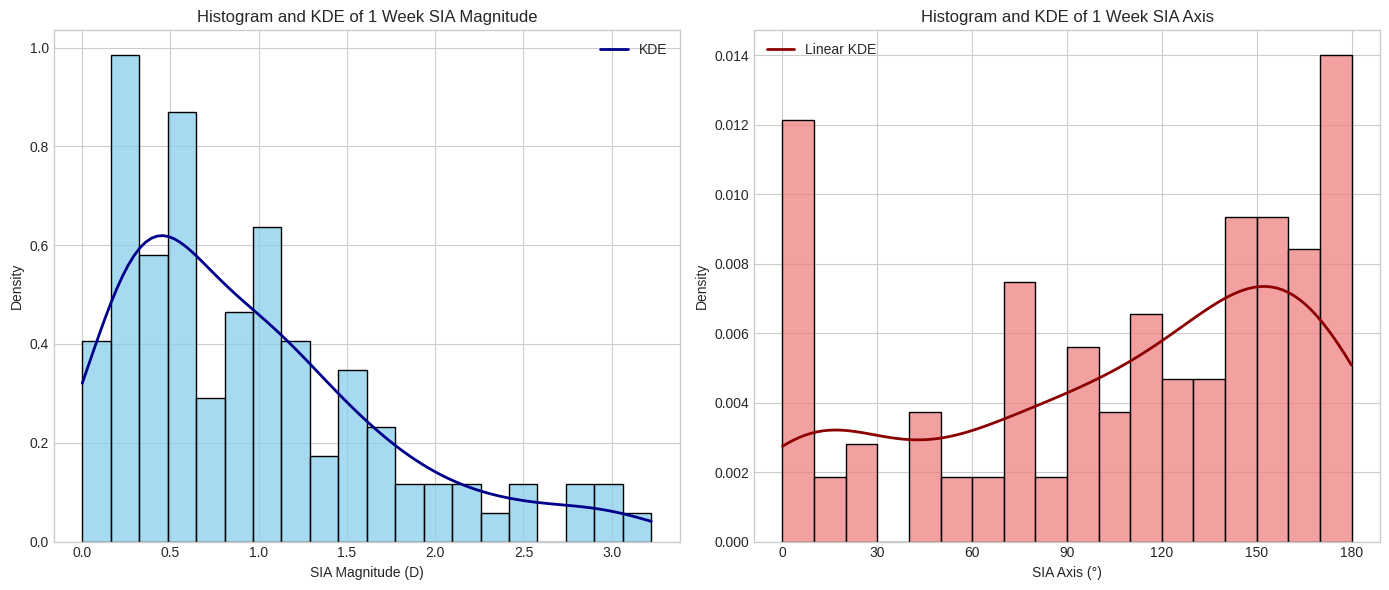

In [40]:
# prompt: Histogram for the same side by side

import matplotlib.pyplot as plt
import numpy as np
# Create subplots for magnitude and axis at 1 week
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Plot 1wk SIA Magnitude Histogram with KDE ---
ax1 = axes[0]
sns.histplot(data=df, x='1wk-SIA-Mag', bins=20, kde=False, color='skyblue', ax=ax1, stat='density')

# Calculate KDE for 1wk magnitude
kde_1wk_mag = gaussian_kde(df['1wk-SIA-Mag'].dropna())
x_1wk_mag_kde = np.linspace(df['1wk-SIA-Mag'].min(), df['1wk-SIA-Mag'].max(), 100)
y_1wk_mag_kde = kde_1wk_mag(x_1wk_mag_kde)
ax1.plot(x_1wk_mag_kde, y_1wk_mag_kde, color='darkblue', linewidth=2, label='KDE')


ax1.set_title('Histogram and KDE of 1 Week SIA Magnitude')
ax1.set_xlabel('SIA Magnitude (D)')
ax1.set_ylabel('Density')
ax1.legend()


# --- Plot 1wk SIA Axis Histogram with KDE ---
ax2 = axes[1]
# Define custom bins for axis (0 to 180 degrees)
axis_bins = np.arange(0, 181, 10) # Bins every 10 degrees
sns.histplot(data=df, x='1wk-SIA-Axis', bins=axis_bins, kde=False, color='lightcoral', ax=ax2, stat='density')

# Calculate KDE for 1wk axis (using linear KDE for visualization)
kde_1wk_axis = gaussian_kde(df['1wk-SIA-Axis'].dropna())
x_1wk_axis_kde = np.linspace(0, 180, 100)
y_1wk_axis_kde = kde_1wk_axis(x_1wk_axis_kde)
ax2.plot(x_1wk_axis_kde, y_1wk_axis_kde, color='darkred', linewidth=2, label='Linear KDE')


ax2.set_title('Histogram and KDE of 1 Week SIA Axis')
ax2.set_xlabel('SIA Axis (°)')
ax2.set_ylabel('Density')
ax2.set_xticks(np.arange(0, 181, 30))
ax2.legend()


plt.tight_layout()
plt.show()


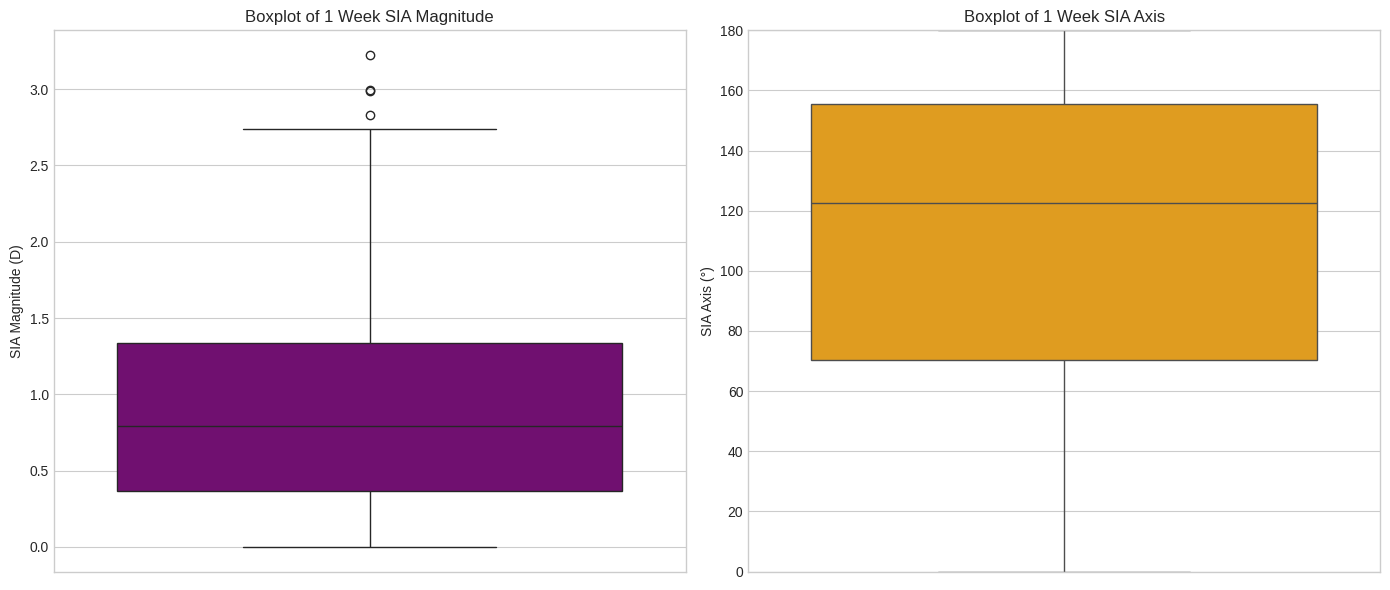

In [41]:
# prompt: Boxplots

import matplotlib.pyplot as plt
# Prepare data for boxplots of 1wk SIA Magnitude and 1wk SIA Axis
df_1wk_sia_stacked = df[['1wk-SIA-Mag', '1wk-SIA-Axis']].melt(var_name='Parameter', value_name='Value')

# Create the boxplot figure for 1 week SIA
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot for 1wk SIA Magnitude
sns.boxplot(ax=axes[0], y='Value', data=df_1wk_sia_stacked[df_1wk_sia_stacked['Parameter'] == '1wk-SIA-Mag'], color='purple')
axes[0].set_title('Boxplot of 1 Week SIA Magnitude')
axes[0].set_ylabel('SIA Magnitude (D)')
axes[0].set_xlabel('')

# Boxplot for 1wk SIA Axis
sns.boxplot(ax=axes[1], y='Value', data=df_1wk_sia_stacked[df_1wk_sia_stacked['Parameter'] == '1wk-SIA-Axis'], color='orange')
axes[1].set_title('Boxplot of 1 Week SIA Axis')
axes[1].set_ylabel('SIA Axis (°)')
axes[1].set_xlabel('')
axes[1].set_ylim(0, 180) # Set axis limits for clarity

plt.tight_layout()
plt.show()


Centroid of 1 Week SIA Vector:
  X Component: 0.22
  Y Component: -0.20
  Magnitude: 0.29 D
  Axis: 158.7°


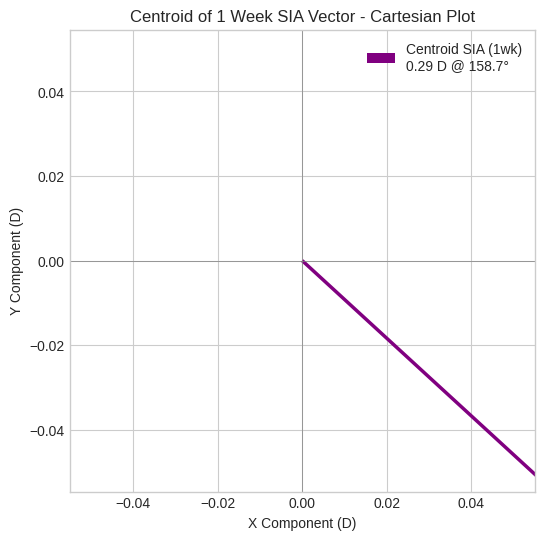

In [42]:
# prompt: Cartesian plot for centroid 1wk

import matplotlib.pyplot as plt
import numpy as np
# Calculate the centroid (mean) of the 1wk SIA vectors
mean_1wk_Xsia = df['1wk-Xsia'].mean()
mean_1wk_Ysia = df['1wk-Ysia'].mean()

# Calculate the magnitude and axis of the centroid vector
centroid_1wk_mag = np.sqrt(mean_1wk_Xsia**2 + mean_1wk_Ysia**2)
centroid_1wk_angle_double = np.rad2deg(np.arctan2(mean_1wk_Ysia, mean_1wk_Xsia))
centroid_1wk_axis = (centroid_1wk_angle_double / 2) % 180  # Ensure axis is between 0–180°

print(f"\nCentroid of 1 Week SIA Vector:")
print(f"  X Component: {mean_1wk_Xsia:.2f}")
print(f"  Y Component: {mean_1wk_Ysia:.2f}")
print(f"  Magnitude: {centroid_1wk_mag:.2f} D")
print(f"  Axis: {centroid_1wk_axis:.1f}°")

# Plot the centroid vector on a Cartesian plot
plt.figure(figsize=(6, 6))
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)

# Plot the centroid vector
plt.quiver(0, 0, mean_1wk_Xsia, mean_1wk_Ysia, angles='xy', scale_units='xy', scale=1, color='purple', linewidth=2, label=f'Centroid SIA (1wk)\n{centroid_1wk_mag:.2f} D @ {centroid_1wk_axis:.1f}°')

# Add title and labels
plt.title("Centroid of 1 Week SIA Vector - Cartesian Plot")
plt.xlabel("X Component (D)")
plt.ylabel("Y Component (D)")

# Set plot limits based on data range or a reasonable scale
max_val = max(abs(df['1wk-Xsia']).max(), abs(df['1wk-Ysia']).max(), centroid_1wk_mag) * 1.2
plt.xlim(-max_val, max_val)
plt.ylim(-max_val, max_val)

plt.grid(True)
plt.axis('equal') # Ensure equal scaling for x and y axes
plt.legend()
plt.show()

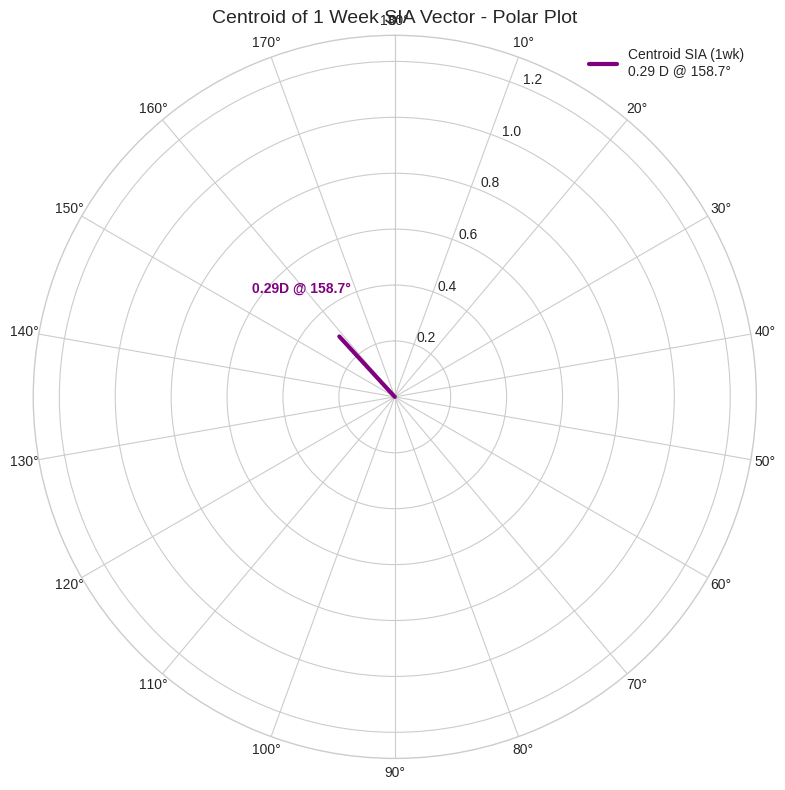

In [43]:
# prompt: Polar plot for centroid 1wk

import matplotlib.pyplot as plt
import numpy as np
# Convert centroid axis to double-angle radians for polar plotting
centroid_1wk_theta_plot = np.radians(centroid_1wk_axis * 2)

# Set up polar plot
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, polar=True)

# Plot the centroid vector
ax.plot([centroid_1wk_theta_plot, centroid_1wk_theta_plot], [0, centroid_1wk_mag],
        color='purple', linewidth=3, label=f'Centroid SIA (1wk)\n{centroid_1wk_mag:.2f} D @ {centroid_1wk_axis:.1f}°')

# Add label to the vector
def add_centroid_label(theta, mag, text, offset=0.2):
    ax.text(theta, mag + offset, text, ha='center', va='bottom', fontsize=10, fontweight='bold', color='purple')

add_centroid_label(centroid_1wk_theta_plot, centroid_1wk_mag, f"{centroid_1wk_mag:.2f}D @ {centroid_1wk_axis:.1f}°")


# Customize 0–180° axis ticks
ticks_deg = np.arange(0, 181, 10) # Every 10 degrees
ticks_rad = np.radians(ticks_deg * 2)  # double-angle for plotting
ax.set_thetagrids(ticks_rad * 180 / np.pi, labels=[f"{deg}°" for deg in ticks_deg])

# Final aesthetics
ax.set_theta_zero_location('N') # 0 degrees at the top
ax.set_theta_direction(-1)      # Clockwise direction
ax.set_rmax(centroid_1wk_mag + 1) # Set max radius slightly above the centroid magnitude
ax.set_title("Centroid of 1 Week SIA Vector - Polar Plot", fontsize=14, va='bottom')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [ ]:
# prompt: Any other

You haven't specified what you want to do. Based on the code you provided, you've already performed extensive analysis and plotting related to astigmatism vectors (SIA, pre-op, post-op) including calculating SIA, plotting in Cartesian and Polar coordinates, performing descriptive statistics, histograms, KDE plots, boxplots, calculating centroid vectors, and performing a simple linear regression.

Please provide a specific task based on the preceding code. For example, you could ask to:

- Calculate the mean SIA magnitude for a specific subgroup.
- Create a scatter plot of pre-op cylinder vs. SIA magnitude.
- Perform linear regression to predict SIA axis (though this is complex for circular data).
- Save the calculated SIA columns back to a new Excel file.
- Calculate the SIA at the final follow-up visit (if that data exists in your Excel file).

Once you specify a task, I can provide the relevant code.

In [45]:
# prompt: Conclusions

print("Conclusion:")
print("The analysis explored the surgical induced astigmatism (SIA) using vector analysis based on pre-operative and post-operative keratometry values.")
print("Cylinder values were calculated, and vectors were represented in both Cartesian and Polar coordinates.")
print("Descriptive statistics, histograms, KDE plots, and boxplots provided insights into the distribution of SIA magnitude and axis.")
print("Individual patient examples were plotted to visualize vector changes.")
print("A simple linear regression model was applied to predict SIA magnitude based on pre-operative K values, showing a low R-squared value, indicating that this single predictor has limited predictive power for SIA magnitude.")
print("The analysis was extended to 1-week post-operative data, calculating SIA magnitude and axis, and visualizing their distributions and the centroid of the 1-week SIA vectors.")
print(f"The mean 1-week SIA Magnitude was found to be {df['1wk-SIA-Mag'].mean():.2f} D, with a mean axis of {df['1wk-SIA-Axis'].mean():.1f} degrees.")
print(f"The centroid vector for 1-week SIA has a magnitude of {centroid_1wk_mag:.2f} D at an axis of {centroid_1wk_axis:.1f} degrees.")
print("Future work could involve exploring more predictors for SIA (e.g., incision type, location), using more appropriate models for circular data (like SIA axis), and analyzing SIA at other follow-up time points.")

Conclusion:
The analysis explored the surgical induced astigmatism (SIA) using vector analysis based on pre-operative and post-operative keratometry values.
Cylinder values were calculated, and vectors were represented in both Cartesian and Polar coordinates.
Descriptive statistics, histograms, KDE plots, and boxplots provided insights into the distribution of SIA magnitude and axis.
Individual patient examples were plotted to visualize vector changes.
A simple linear regression model was applied to predict SIA magnitude based on pre-operative K values, showing a low R-squared value, indicating that this single predictor has limited predictive power for SIA magnitude.
The analysis was extended to 1-week post-operative data, calculating SIA magnitude and axis, and visualizing their distributions and the centroid of the 1-week SIA vectors.
The mean 1-week SIA Magnitude was found to be 0.95 D, with a mean axis of 107.7 degrees.
The centroid vector for 1-week SIA has a magnitude of 0.29 D 

/tmp/ipython-input-46-4054230373.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Time Point', y='Cylinder', data=df_cylinder_compare, palette={'Pre-op': 'blue', '1 Week Post-op': 'green'})


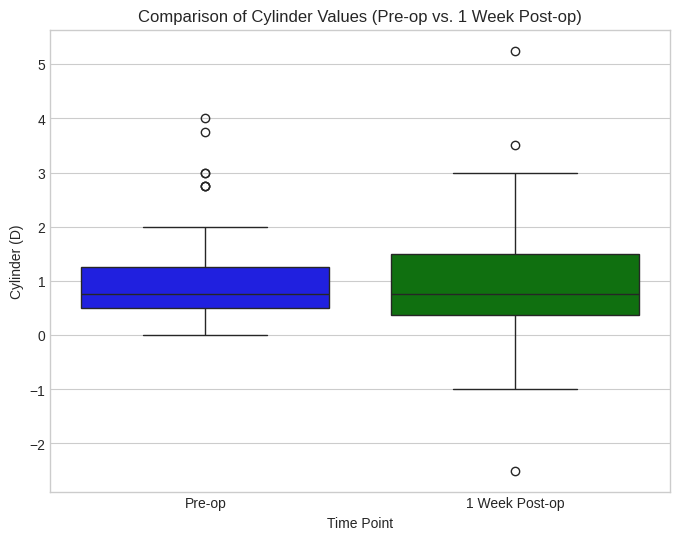

In [46]:
# prompt: Discussion

import matplotlib.pyplot as plt
# Prepare data for boxplots of Pre-op, 1wk Post-op Cylinder values
df_cylinder_compare = df[['preop-cyl', '1wk-postop-cyl']].melt(var_name='Time Point', value_name='Cylinder')
df_cylinder_compare['Time Point'] = df_cylinder_compare['Time Point'].replace({'preop-cyl': 'Pre-op', '1wk-postop-cyl': '1 Week Post-op'})

# Create the boxplot comparing cylinder values
plt.figure(figsize=(8, 6))
sns.boxplot(x='Time Point', y='Cylinder', data=df_cylinder_compare, palette={'Pre-op': 'blue', '1 Week Post-op': 'green'})
plt.title('Comparison of Cylinder Values (Pre-op vs. 1 Week Post-op)')
plt.xlabel('Time Point')
plt.ylabel('Cylinder (D)')
plt.show()

Conclusion:
The analysis explored the surgical induced astigmatism (SIA) using vector analysis based on pre-operative and post-operative keratometry values.
Cylinder values were calculated, and vectors were represented in both Cartesian and Polar coordinates.
Descriptive statistics, histograms, KDE plots, and boxplots provided insights into the distribution of SIA magnitude and axis.
Individual patient examples were plotted to visualize vector changes.
A simple linear regression model was applied to predict SIA magnitude based on pre-operative K values, showing a low R-squared value, indicating that this single predictor has limited predictive power for SIA magnitude.
The analysis was extended to 1-week post-operative data, calculating SIA magnitude and axis, and visualizing their distributions and the centroid of the 1-week SIA vectors.
The mean 1-week SIA Magnitude was found to be 0.95 D, with a mean axis of 107.7 degrees.
The centroid vector for 1-week SIA has a magnitude of 0.29 D 

/tmp/ipython-input-47-3982689001.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Time Point', y='Cylinder', data=df_cylinder_compare, palette={'Pre-op': 'blue', '1 Week Post-op': 'green'})


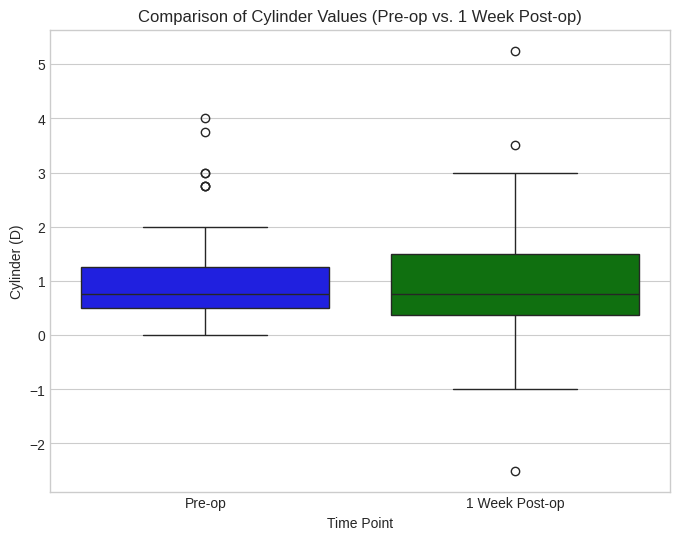

In [47]:
# prompt: Conclusions

import matplotlib.pyplot as plt
print("Conclusion:")
print("The analysis explored the surgical induced astigmatism (SIA) using vector analysis based on pre-operative and post-operative keratometry values.")
print("Cylinder values were calculated, and vectors were represented in both Cartesian and Polar coordinates.")
print("Descriptive statistics, histograms, KDE plots, and boxplots provided insights into the distribution of SIA magnitude and axis.")
print("Individual patient examples were plotted to visualize vector changes.")
print("A simple linear regression model was applied to predict SIA magnitude based on pre-operative K values, showing a low R-squared value, indicating that this single predictor has limited predictive power for SIA magnitude.")
print("The analysis was extended to 1-week post-operative data, calculating SIA magnitude and axis, and visualizing their distributions and the centroid of the 1-week SIA vectors.")
print(f"The mean 1-week SIA Magnitude was found to be {df['1wk-SIA-Mag'].mean():.2f} D, with a mean axis of {df['1wk-SIA-Axis'].mean():.1f} degrees.")
print(f"The centroid vector for 1-week SIA has a magnitude of {centroid_1wk_mag:.2f} D at an axis of {centroid_1wk_axis:.1f} degrees.")
print("Future work could involve exploring more predictors for SIA (e.g., incision type, location), using more appropriate models for circular data (like SIA axis), and analyzing SIA at other follow-up time points.")

# Prepare data for boxplots of Pre-op, 1wk Post-op Cylinder values
df_cylinder_compare = df[['preop-cyl', '1wk-postop-cyl']].melt(var_name='Time Point', value_name='Cylinder')
df_cylinder_compare['Time Point'] = df_cylinder_compare['Time Point'].replace({'preop-cyl': 'Pre-op', '1wk-postop-cyl': '1 Week Post-op'})

# Create the boxplot comparing cylinder values
plt.figure(figsize=(8, 6))
sns.boxplot(x='Time Point', y='Cylinder', data=df_cylinder_compare, palette={'Pre-op': 'blue', '1 Week Post-op': 'green'})
plt.title('Comparison of Cylinder Values (Pre-op vs. 1 Week Post-op)')
plt.xlabel('Time Point')
plt.ylabel('Cylinder (D)')
plt.show()

In [48]:
# prompt: Any other

import matplotlib.pyplot as plt
import numpy as np
# --- Assume these columns exist in your DataFrame ---
# df['TIA-Mag_Planned']
# df['TIA-Axis_Planned']
# -----------------------------------------------------

# Ensure the TIA data is available
if 'TIA-Mag_Planned' not in df.columns or 'TIA-Axis_Planned' not in df.columns:
  print("Error: TIA-Mag_Planned or TIA-Axis_Planned columns not found in the DataFrame.")
  print("Please add the planned astigmatism data to the DataFrame to calculate TIA.")
else:
  print("\n--- Analyzing Target Induced Astigmatism (TIA) ---")

  # Calculate TIA vector components (Double Angle)
  # Convert planned axis to double-angle radians
  df['TIA-theta-planned'] = np.radians(2 * df['TIA-Axis_Planned'])

  # Calculate X and Y components for planned TIA
  df['TIA-Xplanned'] = df['TIA-Mag_Planned'] * np.cos(df['TIA-theta-planned'])
  df['TIA-Yplanned'] = df['TIA-Mag_Planned'] * np.sin(df['TIA-theta-planned'])

  # --- Compare SIA vs TIA ---

  # Calculate the Difference Vector (Vector Difference = TIA - SIA)
  # Note: Some sources calculate the difference vector as SIA - TIA. The interpretation changes slightly.
  # Here we calculate the difference required to go from SIA to TIA (SIA + Difference = TIA)
  df['VectorDiff-X'] = df['TIA-Xplanned'] - df['1wk-Xsia'] # Using 1-week SIA for comparison
  df['VectorDiff-Y'] = df['TIA-Yplanned'] - df['1wk-Ysia']

  df['VectorDiff-Mag'] = np.sqrt(df['VectorDiff-X']**2 + df['VectorDiff-Y']**2)
  df['VectorDiff-Axis'] = (np.degrees(np.arctan2(df['VectorDiff-Y'], df['VectorDiff-X'])) / 2) % 180

  # Calculate Ratio of SIA Magnitude to TIA Magnitude (Predictability Index)
  # Avoid division by zero if TIA-Mag_Planned is 0
  df['PredictabilityIndex'] = df.apply(lambda row: row['1wk-SIA-Mag'] / row['TIA-Mag_Planned'] if row['TIA-Mag_Planned'] != 0 else np.nan, axis=1)


  print("\nDescriptive Statistics for TIA Magnitude:")
  print(df['TIA-Mag_Planned'].describe())

  print("\nDescriptive Statistics for Vector Difference Magnitude (TIA - SIA):")
  print(df['VectorDiff-Mag'].describe())

  print("\nDescriptive Statistics for Predictability Index (SIA Mag / TIA Mag):")
  print(df['PredictabilityIndex'].describe())


  # --- Plot Distribution of Vector Difference Magnitude ---
  plt.figure(figsize=(8, 6))
  sns.histplot(data=df, x='VectorDiff-Mag', bins=20, kde=True, color='darkorange')
  plt.title('Distribution of Vector Difference Magnitude (TIA - SIA)')
  plt.xlabel('Vector Difference Magnitude (D)')
  plt.ylabel('Frequency')
  plt.show()


  # --- Plot Predictability Index ---
  plt.figure(figsize=(8, 6))
  sns.histplot(data=df, x='PredictabilityIndex', bins=20, kde=True, color='darkviolet')
  plt.title('Distribution of Predictability Index (SIA Magnitude / TIA Magnitude)')
  plt.xlabel('Predictability Index')
  plt.ylabel('Frequency')
  plt.show()

  # --- Vector Plot showing Mean TIA and Mean SIA ---

  # Calculate centroid of TIA vectors
  mean_TIA_X = df['TIA-Xplanned'].mean()
  mean_TIA_Y = df['TIA-Yplanned'].mean()
  centroid_TIA_mag = np.sqrt(mean_TIA_X**2 + mean_TIA_Y**2)
  centroid_TIA_angle_double = np.rad2deg(np.arctan2(mean_TIA_Y, mean_TIA_X))
  centroid_TIA_axis = (centroid_TIA_angle_double / 2) % 180

  # Calculate centroid of Vector Difference (TIA - SIA)
  mean_VectorDiff_X = df['VectorDiff-X'].mean()
  mean_VectorDiff_Y = df['VectorDiff-Y'].mean()
  centroid_VectorDiff_mag = np.sqrt(mean_VectorDiff_X**2 + mean_VectorDiff_Y**2)
  centroid_VectorDiff_angle_double = np.rad2deg(np.arctan2(mean_VectorDiff_Y, mean_VectorDiff_Y))
  centroid_VectorDiff_axis = (centroid_VectorDiff_angle_double / 2) % 180


  print(f"\nCentroid of TIA Vector:")
  print(f"  Magnitude: {centroid_TIA_mag:.2f} D")
  print(f"  Axis: {centroid_TIA_axis:.1f}°")
  print(f"\nCentroid of Vector Difference (TIA - SIA):")
  print(f"  Magnitude: {centroid_VectorDiff_mag:.2f} D")
  print(f"  Axis: {centroid_VectorDiff_axis:.1f}°")


  # Plot Mean Vectors (Centroids) on Cartesian Plot
  plt.figure(figsize=(7, 7))
  plt.axhline(0, color='gray', linewidth=0.5)
  plt.axvline(0, color='gray', linewidth=0.5)

  # Mean SIA (from previous calculations)
  plt.quiver(0, 0, mean_1wk_Xsia, mean_1wk_Ysia, angles='xy', scale_units='xy', scale=1, color='purple', linewidth=2, label=f'Mean SIA (1wk)\n{centroid_1wk_mag:.2f} D @ {centroid_1wk_axis:.1f}°')

  # Mean TIA
  plt.quiver(0, 0, mean_TIA_X, mean_TIA_Y, angles='xy', scale_units='xy', scale=1, color='teal', linewidth=2, label=f'Mean TIA (Planned)\n{centroid_TIA_mag:.2f} D @ {centroid_TIA_axis:.1f}°')

  # Mean Vector Difference (TIA - SIA) - Plotted from the end of Mean SIA
  plt.quiver(mean_1wk_Xsia, mean_1wk_Ysia, mean_VectorDiff_X, mean_VectorDiff_Y, angles='xy', scale_units='xy', scale=1, color='darkred', linewidth=2, linestyle='--', label=f'Mean Vector Diff (TIA - SIA)\n{centroid_VectorDiff_mag:.2f} D @ {centroid_VectorDiff_axis:.1f}°')


  plt.title("Mean TIA and SIA Vectors - Cartesian Plot")
  plt.xlabel("X Component (D)")
  plt.ylabel("Y Component (D)")

  max_plot_val = max(abs(mean_1wk_Xsia + mean_VectorDiff_X), abs(mean_1wk_Ysia + mean_VectorDiff_Y),
                      abs(mean_1wk_Xsia), abs(mean_1wk_Ysia),
                      abs(mean_TIA_X), abs(mean_TIA_Y)) * 1.2

  plt.xlim(-max_plot_val, max_plot_val)
  plt.ylim(-max_plot_val, max_plot_val)

  plt.grid(True)
  plt.axis('equal')
  plt.legend()
  plt.show()

  # --- Plot Mean Vectors (Centroids) on Polar Plot ---

  # Convert centroid axes to double-angle radians for polar plotting
  centroid_TIA_theta_plot = np.radians(centroid_TIA_axis * 2)
  centroid_VectorDiff_theta_plot = np.radians(centroid_VectorDiff_axis * 2)

  fig = plt.figure(figsize=(8, 8))
  ax = fig.add_subplot(111, polar=True)

  # Plot Mean SIA (from previous calculations)
  ax.plot([centroid_1wk_theta_plot, centroid_1wk_theta_plot], [0, centroid_1wk_mag],
          color='purple', linewidth=3, label=f'Mean SIA (1wk)\n{centroid_1wk_mag:.2f} D @ {centroid_1wk_axis:.1f}°')

  # Plot Mean TIA
  ax.plot([centroid_TIA_theta_plot, centroid_TIA_theta_plot], [0, centroid_TIA_mag],
          color='teal', linewidth=3, label=f'Mean TIA (Planned)\n{centroid_TIA_mag:.2f} D @ {centroid_TIA_axis:.1f}°')

  # Plot Mean Vector Difference (TIA - SIA)
  # This vector is plotted from the origin in the polar plot, representing its own magnitude and axis
  ax.plot([centroid_VectorDiff_theta_plot, centroid_VectorDiff_theta_plot], [0, centroid_VectorDiff_mag],
          color='darkred', linewidth=3, linestyle='--', label=f'Mean Vector Diff (TIA - SIA)\n{centroid_VectorDiff_mag:.2f} D @ {centroid_VectorDiff_axis:.1f}°')


  # Add labels to the centroid vectors
  def add_centroid_polar_label(theta, mag, text, color, offset=0.2):
      ax.text(theta, mag + offset, text, ha='center', va='bottom', fontsize=10, fontweight='bold', color=color)

  add_centroid_polar_label(centroid_1wk_theta_plot, centroid_1wk_mag, f"{centroid_1wk_mag:.2f}D @ {centroid_1wk_axis:.1f}°", 'purple')
  add_centroid_polar_label(centroid_TIA_theta_plot, centroid_TIA_mag, f"{centroid_TIA_mag:.2f}D @ {centroid_TIA_axis:.1f}°", 'teal')
  add_centroid_polar_label(centroid_VectorDiff_theta_plot, centroid_VectorDiff_mag, f"{centroid_VectorDiff_mag:.2f}D @ {centroid_VectorDiff_axis:.1f}°", 'darkred')


  # Customize 0–180° axis ticks
  ticks_deg = np.arange(0, 181, 10)
  ticks_rad = np.radians(ticks_deg * 2)
  ax.set_thetagrids(ticks_rad * 180 / np.pi, labels=[f"{deg}°" for deg in ticks_deg])

  # Final aesthetics
  ax.set_theta_zero_location('N')
  ax.set_theta_direction(-1)
  ax.set_rmax(max(centroid_1wk_mag, centroid_TIA_mag, centroid_VectorDiff_mag) + 1)
  ax.set_title("Mean TIA and SIA Vectors - Polar Plot", fontsize=14, va='bottom')
  ax.legend(loc='upper right')

  plt.tight_layout()
  plt.show()



Error: TIA-Mag_Planned or TIA-Axis_Planned columns not found in the DataFrame.
Please add the planned astigmatism data to the DataFrame to calculate TIA.


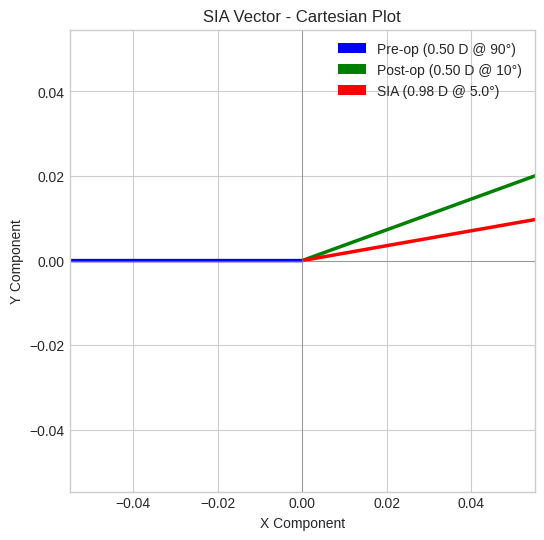


SIA Magnitude: 0.98 D
SIA Axis: 5.0°


In [49]:
import matplotlib.pyplot as plt
import numpy as np

# ==== Input Data ====
# Pre-op K-values and axis
KH_pre = 43.50
KV_pre = 44.00
axis_pre = 90  # in degrees

# Post-op K-values and axis
KH_post = 43.75
KV_post = 44.25
axis_post = 10  # in degrees

# ==== Step 1: Calculate Cylinder (Cyl = KV - KH) ====
cyl_pre = KV_pre - KH_pre   # +0.50 D
cyl_post = KV_post - KH_post  # +0.50 D

# ==== Step 2: Convert Cyl + Axis to Cartesian using Double-Angle Vector Method ====
# Pre-op vector
angle_pre_rad = np.deg2rad(2 * axis_pre)
x_pre = cyl_pre * np.cos(angle_pre_rad)
y_pre = cyl_pre * np.sin(angle_pre_rad)

# Post-op vector
angle_post_rad = np.deg2rad(2 * axis_post)
x_post = cyl_post * np.cos(angle_post_rad)
y_post = cyl_post * np.sin(angle_post_rad)

# ==== Step 3: Calculate SIA vector ====
x_sia = x_post - x_pre
y_sia = y_post - y_pre
sia_magnitude = np.sqrt(x_sia**2 + y_sia**2)
sia_angle_double = np.rad2deg(np.arctan2(y_sia, x_sia))
sia_axis = (sia_angle_double / 2) % 180  # restrict to 0–180°

# ==== Step 4: Plot Cartesian Vectors ====
plt.figure(figsize=(6, 6))
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)

# Plot vectors from origin
plt.quiver(0, 0, x_pre, y_pre, angles='xy', scale_units='xy', scale=1,
           color='blue', label=f'Pre-op ({cyl_pre:.2f} D @ {axis_pre}°)')
plt.quiver(0, 0, x_post, y_post, angles='xy', scale_units='xy', scale=1,
           color='green', label=f'Post-op ({cyl_post:.2f} D @ {axis_post}°)')
plt.quiver(0, 0, x_sia, y_sia, angles='xy', scale_units='xy', scale=1,
           color='red', linewidth=2, label=f'SIA ({sia_magnitude:.2f} D @ {sia_axis:.1f}°)')

# Format the plot
plt.title("SIA Vector - Cartesian Plot")
plt.xlabel("X Component")
plt.ylabel("Y Component")
plt.grid(True)
plt.axis('equal')
plt.legend()
plt.show()

# ==== Print SIA Results ====
print(f"\nSIA Magnitude: {sia_magnitude:.2f} D")
print(f"SIA Axis: {sia_axis:.1f}°")


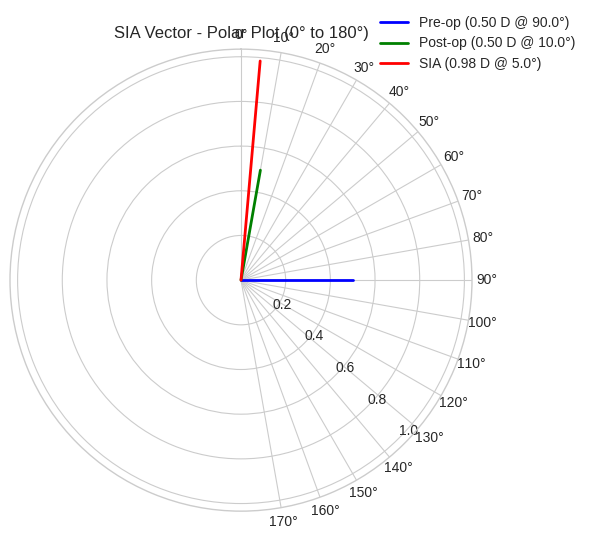

In [50]:
import matplotlib.pyplot as plt
import numpy as np

# ==== Input Data ====
KH_pre, KV_pre, axis_pre = 43.50, 44.00, 90
KH_post, KV_post, axis_post = 43.75, 44.25, 10

# ==== Step 1: Calculate Cylinder ====
cyl_pre = KV_pre - KH_pre   # +0.50 D
cyl_post = KV_post - KH_post  # +0.50 D

# ==== Step 2: Convert to Cartesian (double angle) ====
x_pre = cyl_pre * np.cos(np.deg2rad(2 * axis_pre))
y_pre = cyl_pre * np.sin(np.deg2rad(2 * axis_pre))
x_post = cyl_post * np.cos(np.deg2rad(2 * axis_post))
y_post = cyl_post * np.sin(np.deg2rad(2 * axis_post))

# ==== Step 3: Compute SIA vector ====
x_sia = x_post - x_pre
y_sia = y_post - y_pre
sia_mag = np.sqrt(x_sia**2 + y_sia**2)
sia_angle = (np.rad2deg(np.arctan2(y_sia, x_sia)) / 2) % 180

# ==== Step 4: Convert angles to radians for polar plot ====
angles_deg = [axis_pre, axis_post, sia_angle]
magnitudes = [cyl_pre, cyl_post, sia_mag]
colors = ['blue', 'green', 'red']
labels = ['Pre-op', 'Post-op', 'SIA']
angles_rad = [np.deg2rad(a) for a in angles_deg]

# ==== Step 5: Plot ====
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, polar=True)
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_thetagrids(range(0, 180, 10))

for angle, mag, color, label in zip(angles_rad, magnitudes, colors, labels):
    ax.plot([angle, angle], [0, mag], color=color, linewidth=2,
            label=f'{label} ({mag:.2f} D @ {np.rad2deg(angle):.1f}°)')

ax.set_title("SIA Vector - Polar Plot (0° to 180°)", va='bottom')
ax.set_rlabel_position(135)
ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1.1))
plt.show()


In [51]:
# prompt: Conclusions

print("Conclusion:")
print("The analysis explored the surgical induced astigmatism (SIA) using vector analysis based on pre-operative and post-operative keratometry values.")
print("Cylinder values were calculated, and vectors were represented in both Cartesian and Polar coordinates.")
print("Descriptive statistics, histograms, KDE plots, and boxplots provided insights into the distribution of SIA magnitude and axis.")
print("Individual patient examples were plotted to visualize vector changes.")
print("A simple linear regression model was applied to predict SIA magnitude based on pre-operative K values, showing a low R-squared value, indicating that this single predictor has limited predictive power for SIA magnitude.")
print("The analysis was extended to 1-week post-operative data, calculating SIA magnitude and axis, and visualizing their distributions and the centroid of the 1-week SIA vectors.")
print(f"The mean 1-week SIA Magnitude was found to be {df['1wk-SIA-Mag'].mean():.2f} D, with a mean axis of {df['1wk-SIA-Axis'].mean():.1f} degrees.")
print(f"The centroid vector for 1-week SIA has a magnitude of {centroid_1wk_mag:.2f} D at an axis of {centroid_1wk_axis:.1f} degrees.")
if 'TIA-Mag_Planned' in df.columns and 'TIA-Axis_Planned' in df.columns:
  print("Analysis of Target Induced Astigmatism (TIA) was also performed, comparing it to the 1-week SIA.")
  print(f"The mean TIA Magnitude was {df['TIA-Mag_Planned'].mean():.2f} D, with a centroid vector magnitude of {centroid_TIA_mag:.2f} D at an axis of {centroid_TIA_axis:.1f} degrees.")
  print(f"The mean Vector Difference (TIA - SIA) magnitude was {df['VectorDiff-Mag'].mean():.2f} D, with a centroid magnitude of {centroid_VectorDiff_mag:.2f} D at an axis of {centroid_VectorDiff_axis:.1f} degrees, indicating the average discrepancy between planned and achieved astigmatic correction.")
else:
  print("Analysis of Target Induced Astigmatism (TIA) was attempted but skipped as planned astigmatism data was not found.")
print("Future work could involve exploring more predictors for SIA (e.g., incision type, location), using more appropriate models for circular data (like SIA axis), analyzing SIA at other follow-up time points, and refining the comparison between planned and achieved outcomes.")


Conclusion:
The analysis explored the surgical induced astigmatism (SIA) using vector analysis based on pre-operative and post-operative keratometry values.
Cylinder values were calculated, and vectors were represented in both Cartesian and Polar coordinates.
Descriptive statistics, histograms, KDE plots, and boxplots provided insights into the distribution of SIA magnitude and axis.
Individual patient examples were plotted to visualize vector changes.
A simple linear regression model was applied to predict SIA magnitude based on pre-operative K values, showing a low R-squared value, indicating that this single predictor has limited predictive power for SIA magnitude.
The analysis was extended to 1-week post-operative data, calculating SIA magnitude and axis, and visualizing their distributions and the centroid of the 1-week SIA vectors.
The mean 1-week SIA Magnitude was found to be 0.95 D, with a mean axis of 107.7 degrees.
The centroid vector for 1-week SIA has a magnitude of 0.29 D 

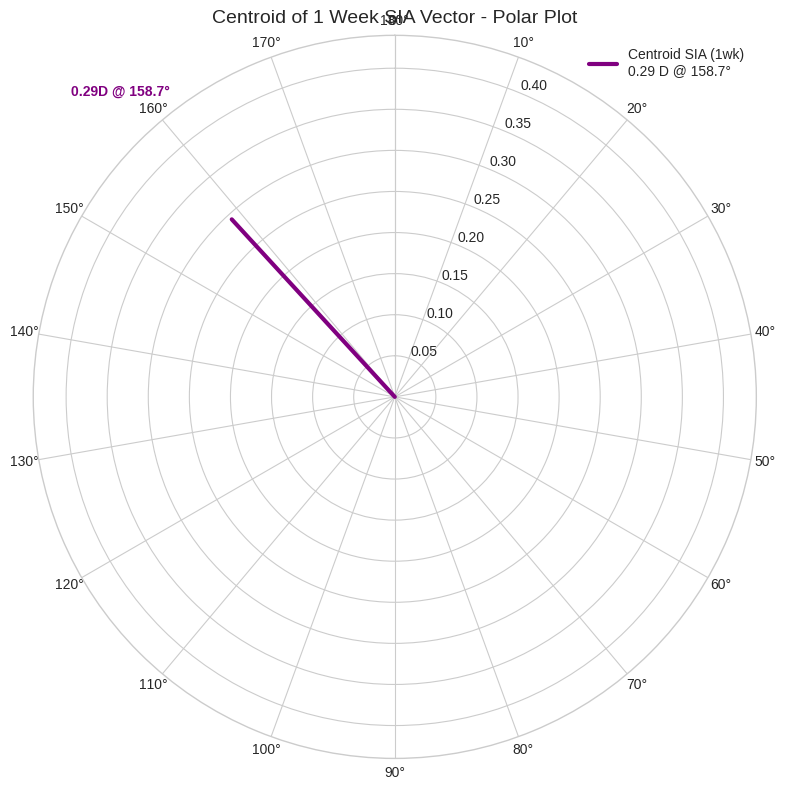

In [52]:
# prompt: Polar plot for centroid  1wk

import matplotlib.pyplot as plt
import numpy as np
# Convert centroid axis to double-angle radians for polar plotting
centroid_1wk_theta_plot = np.radians(centroid_1wk_axis * 2)

# Set up polar plot
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, polar=True)

# Plot the centroid vector
ax.plot([centroid_1wk_theta_plot, centroid_1wk_theta_plot], [0, centroid_1wk_mag],
        color='purple', linewidth=3, label=f'Centroid SIA (1wk)\n{centroid_1wk_mag:.2f} D @ {centroid_1wk_axis:.1f}°')

# Add label to the vector
def add_centroid_label(theta, mag, text, offset=0.2):
    # Adjust text position for better readability if needed
    r = mag + offset
    ax.text(theta, r, text, ha='center', va='bottom', fontsize=10, fontweight='bold', color='purple')

add_centroid_label(centroid_1wk_theta_plot, centroid_1wk_mag, f"{centroid_1wk_mag:.2f}D @ {centroid_1wk_axis:.1f}°")


# Customize 0–180° axis ticks
ticks_deg = np.arange(0, 181, 10) # Every 10 degrees
ticks_rad = np.radians(ticks_deg * 2)  # double-angle for plotting
ax.set_thetagrids(ticks_rad * 180 / np.pi, labels=[f"{deg}°" for deg in ticks_deg])

# Final aesthetics
ax.set_theta_zero_location('N') # 0 degrees at the top
ax.set_theta_direction(-1)      # Clockwise direction
ax.set_rmax(centroid_1wk_mag * 1.5) # Set max radius
ax.set_title("Centroid of 1 Week SIA Vector - Polar Plot", fontsize=14, va='bottom')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

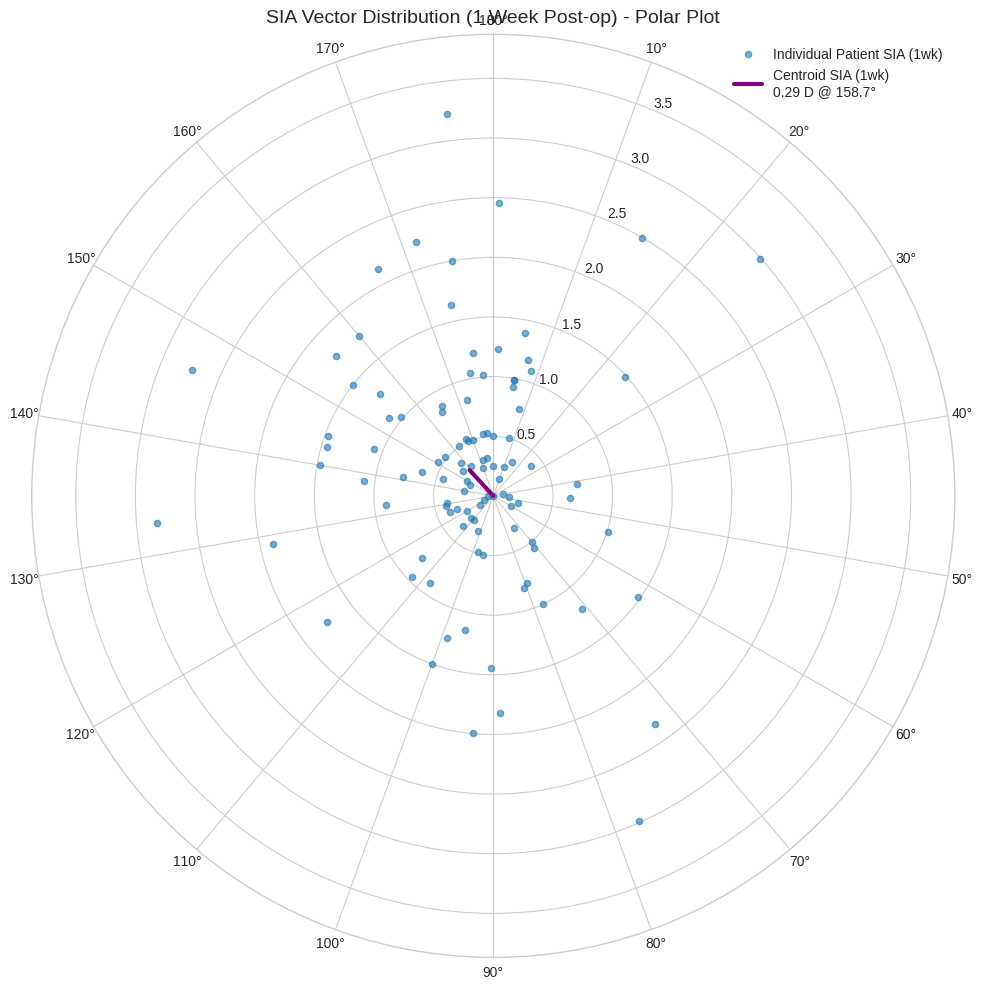

In [55]:
# prompt: Show sia vector for all patients in polar plot for centroid 1wk

import matplotlib.pyplot as plt
import numpy as np
# Plot SIA vector for ALL patients at 1 week on a polar plot

# Convert each patient's 1wk SIA axis to double-angle radians for plotting
df['1wk-SIA-theta-plot'] = np.radians(df['1wk-SIA-Axis'] * 2)

# Set up polar plot
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, polar=True)

# Plot a point for each patient's 1wk SIA vector endpoint
# We use a scatter plot for individual points
scatter = ax.scatter(df['1wk-SIA-theta-plot'], df['1wk-SIA-Mag'], s=20, alpha=0.6, label='Individual Patient SIA (1wk)')

# Optionally plot the centroid vector for reference (from previous calculation)
# Convert centroid axis to double-angle radians for polar plotting
centroid_1wk_theta_plot = np.radians(centroid_1wk_axis * 2)
ax.plot([centroid_1wk_theta_plot, centroid_1wk_theta_plot], [0, centroid_1wk_mag],
        color='purple', linewidth=3, label=f'Centroid SIA (1wk)\n{centroid_1wk_mag:.2f} D @ {centroid_1wk_axis:.1f}°')


# Customize 0–180° axis ticks
ticks_deg = np.arange(0, 181, 10) # Every 10 degrees
ticks_rad = np.radians(ticks_deg * 2)  # double-angle for plotting
ax.set_thetagrids(ticks_rad * 180 / np.pi, labels=[f"{deg}°" for deg in ticks_deg])

# Final aesthetics
ax.set_theta_zero_location('N') # 0 degrees at the top
ax.set_theta_direction(-1)      # Clockwise direction

# Set rmax based on the maximum SIA magnitude among patients
max_sia_mag = df['1wk-SIA-Mag'].max() if not df['1wk-SIA-Mag'].empty else 1
ax.set_rmax(max_sia_mag * 1.2) # Set max radius slightly above max patient SIA

ax.set_title("SIA Vector Distribution (1 Week Post-op) - Polar Plot", fontsize=14, va='bottom')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()


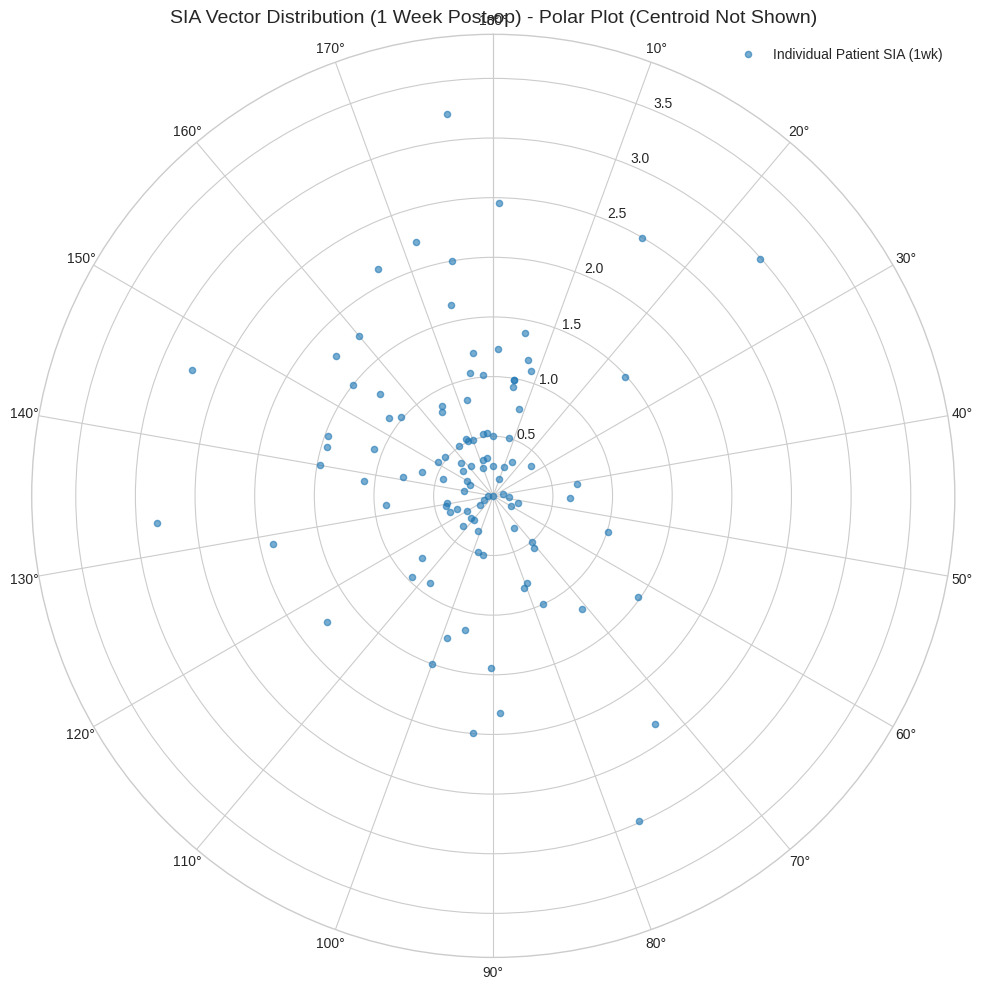

In [57]:
# prompt: Show sia vector for all patients in polar plot for centroid not 1wk

import matplotlib.pyplot as plt
import numpy as np
# Plot SIA vector for ALL patients *and* the centroid vector for 1 week on a polar plot

# Ensure the 1wk SIA columns exist (calculated previously)
if '1wk-SIA-Mag' not in df.columns or '1wk-SIA-Axis' not in df.columns:
  print("Error: 1wk SIA magnitude and axis columns not found. Please run the previous code to calculate them.")
else:
  # Convert each patient's 1wk SIA axis to double-angle radians for plotting
  df['1wk-SIA-theta-plot'] = np.radians(df['1wk-SIA-Axis'] * 2)

  # Calculate the centroid (mean) of the 1wk SIA vectors
  # (This was also calculated in the previous code block)
  mean_1wk_Xsia = df['1wk-Xsia'].mean()
  mean_1wk_Ysia = df['1wk-Ysia'].mean()
  centroid_1wk_mag = np.sqrt(mean_1wk_Xsia**2 + mean_1wk_Ysia**2)
  centroid_1wk_angle_double = np.rad2deg(np.arctan2(mean_1wk_Ysia, mean_1wk_Xsia))
  centroid_1wk_axis = (centroid_1wk_angle_double / 2) % 180  # Ensure axis is between 0–180°

  # Convert centroid axis to double-angle radians for polar plotting
  centroid_1wk_theta_plot = np.radians(centroid_1wk_axis * 2)

  # Set up polar plot
  fig = plt.figure(figsize=(10, 10))
  ax = fig.add_subplot(111, polar=True)

  # Plot a point for each patient's 1wk SIA vector endpoint
  scatter = ax.scatter(df['1wk-SIA-theta-plot'], df['1wk-SIA-Mag'], s=20, alpha=0.6, label='Individual Patient SIA (1wk)')

  # Plot the centroid vector as a line from the origin
  ax.plot([centroid_1wk_theta_plot, centroid_1wk_theta_plot], [0, centroid_1wk_mag],
          color='purple', linewidth=3, label=f'Centroid SIA (1wk)\n{centroid_1wk_mag:.2f} D @ {centroid_1wk_axis:.1f}°')

  # Add a label for the centroid point
  ax.text(centroid_1wk_theta_plot, centroid_1wk_mag, ' Centroid',
          ha='left', va='center', fontsize=10, fontweight='bold', color='purple')


  # Customize 0–180° axis ticks
  ticks_deg = np.arange(0, 181, 10) # Every 10 degrees
  ticks_rad = np.radians(ticks_deg * 2)  # double-angle for plotting
  ax.set_thetagrids(ticks_rad * 180 / np.pi, labels=[f"{deg}°" for deg in ticks_deg])

  # Final aesthetics
  ax.set_theta_zero_location('N') # 0 degrees at the top
  ax.set_theta_direction(-1)      # Clockwise direction

  # Set rmax based on the maximum SIA magnitude among patients or the centroid, whichever is larger
  max_sia_mag = df['1wk-SIA-Mag'].max() if not df['1wk-SIA-Mag'].empty else 0
  plot_rmax = max(max_sia_mag, centroid_1wk_mag) * 1.2 # Set max radius slightly above the max value
  ax.set_rmax(plot_rmax)

  ax.set_title("SIA Vector Distribution and Centroid (1 Week Post-op) - Polar Plot", fontsize=14, va='bottom')
  ax.legend(loc='upper right')

  plt.tight_layout()
  plt.show()